---
<h2 style="text-align: center;">
   <font size="5">Whats your used car value ?</font>
</h2>

![Car Price](images/car_price.png)

---


### CRISP-DM Framework Introduction 
<p align="center"> <img src="images/crisp.png" alt="CRISP-DM Process"> </p>

To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called **CRISP-DM**. This process provides a framework for working through a data problem.

Your first step in this application will be to read through a brief overview of **CRISP-DM** [here](https://www.datascience-pm.com/crisp-dm-2/).  

---


### 🧠 Framing the Data Problem
---

From a 💼 **business perspective**, our goal is to identify the key factors influencing used car prices. According to the **CRISP-DM** framework, this business understanding must be translated into a clear data problem definition.

🔍 In technical terms, the task is to develop a **supervised regression model** that predicts the market price of used vehicles based on various vehicle attributes. These features include :

- 🚗 Manufacturer & Model  
- 📅 Year  
- 📉 Odometer  
- 🛠️ Condition  
- ⛽ Fuel Type  
- ⚙️ Engine Type  
- 🧪 Cylinder  

🧪 The data science process involves identifying and quantifying the most influential predictors using **exploratory data analysis (EDA)** and **feature engineering** techniques. 

🎯 The ultimate objective is to enhance **pricing precision**, derive **actionable insights**, and support **data-informed decision making** in the used car market.

---

In [1]:
%%capture
%pip install plotly
%pip install matplotlib
%pip install pandas
%pip install seaborn
%pip install numpy
%pip install scikit-learn
%pip install xgboost
%pip install vininfo
%pip install vin
%pip install pyvin
%pip install aiohttp
%pip install category_encoders

In [2]:
# Standard libraries
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# VIN decoding
from vin import VIN

# Scikit-learn core utilities
from sklearn import set_config
from sklearn.model_selection import train_test_split, GridSearchCV, ParameterGrid
from sklearn.metrics import mean_squared_error, silhouette_score,r2_score
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.model_selection import KFold
from sklearn.compose import ColumnTransformer
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA

# Imputation
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer, KNNImputer, SimpleImputer

# Preprocessing
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder, PolynomialFeatures

# Models
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.cluster import DBSCAN

# Category encoders
import category_encoders as ce
from category_encoders.james_stein import JamesSteinEncoder
from category_encoders import TargetEncoder
from sklearn import set_config

set_config(display='diagram')


---
## 📊 1. Data Understanding

Understanding your data is a critical first step in any data science or machine learning project. This phase involves collecting, describing, and exploring the data to discover key patterns, relationships, and issues.

---

### 🧩 Key Tasks

- 📋 **Data Description**  
  Summarize the dataset: variable types, missing values, basic statistics (mean, median, etc.).

- 📈 **Data Exploration**  
  Use visualizations (histograms, scatter plots, correlation matrices) to identify patterns, trends, or anomalies.

- ✅ **Data Quality Checks**  
  Detect and handle missing, duplicated, or inconsistent entries to ensure reliability.

---

In [3]:
# Read the data
car_raw=pd.read_csv('data/vehicles.csv')
car_raw.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [4]:
# Study the NUll values for differnt columns 
car_raw.isna().sum()

id                   0
region               0
price                0
year              1205
manufacturer     17646
model             5277
condition       174104
cylinders       177678
fuel              3013
odometer          4400
title_status      8242
transmission      2556
VIN             161042
drive           130567
size            306361
type             92858
paint_color     130203
state                0
dtype: int64

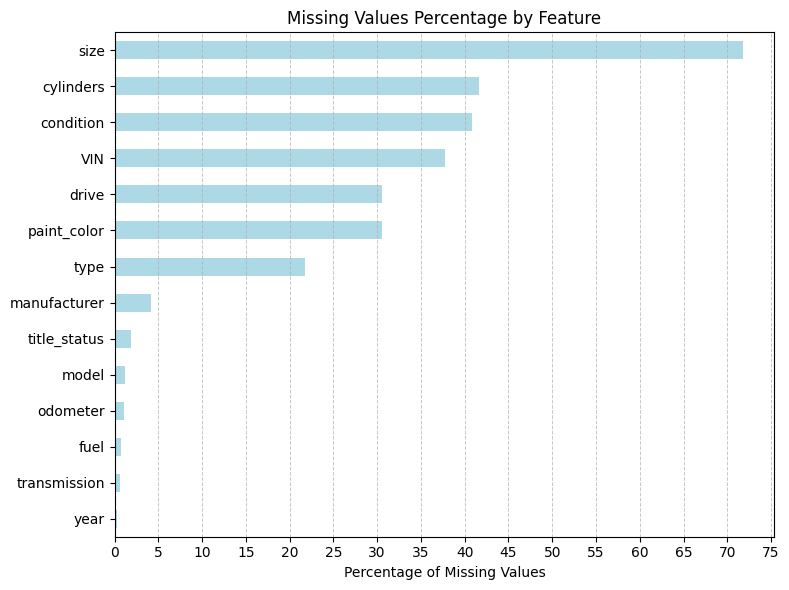

In [5]:
null_percent = car_raw.isnull().mean() * 100
null_percent = null_percent[null_percent > 0].sort_values(ascending=True)
max_percent = null_percent.max()
# Plot
plt.figure(figsize=(8, 6))
null_percent.plot(kind='barh', color='lightblue')
plt.xlabel('Percentage of Missing Values')
plt.title('Missing Values Percentage by Feature')
plt.xticks(np.arange(0, max_percent + 5, 5))
plt.grid(axis='x', linestyle='--', linewidth=0.7, alpha=0.7)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
# Save the plot
plt.savefig("images/Missing_initial_Null.png")  # Saves as PNG
plt.show()

---
## 2. Data Preparation 


---
#### 🧹 2.1 Data Wrangling
---
<span style="color:black">🔻 We reduce distinct values for `model`, `type`, and `manufacturer`.  
📌 Note: For better data quality and consistency, the column `I_model` is retained.</span>  


<span style="color:black">🛠️ We plan to impute `model`, `year`, `manufacturer`, and `type` using the `VIN` package.  
🆔 Note: Columns with prefix `I_` represent imputed columns.</span>

---

In [6]:
# Use VIN number to extract meaningful information like year,manufacturer,type,model

def extract_vin_info(vin_number):
    try:
        vin_obj = VIN(vin_number)
        return vin_obj.model, vin_obj.model_year, vin_obj.manufacturer,vin_obj.body_class
    except:
        return None, None, None

# Apply the function to the 'VIN' column
car_raw[['I_model', 'I_year', 'I_manufacturer','I_type']] = car_raw['VIN'].apply(lambda x: pd.Series(extract_vin_info(x) if pd.notna(x) else (None, None, None))).fillna(method='ffill')


/var/folders/73/9j149hs9505dw9fxc__snb1h0000gn/T/ipykernel_16833/332000345.py:11: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  car_raw[['I_model', 'I_year', 'I_manufacturer','I_type']] = car_raw['VIN'].apply(lambda x: pd.Series(extract_vin_info(x) if pd.notna(x) else (None, None, None))).fillna(method='ffill')


In [7]:
# Update the 'year' ,'type','model' 'manufacturer' columns with the extracted information
car_raw['year'] = car_raw['year'].fillna(car_raw['I_year'])
car_raw['manufacturer'] = car_raw['manufacturer'].fillna(car_raw['I_manufacturer'])
car_raw['type'] = car_raw['type'].fillna(car_raw['I_type'])
car_raw['model'] = car_raw['model'].fillna(car_raw['I_model'])

---

#### 🔧 2.1 Data Wrangling

<span style="color:black; font-weight:">
⚠️ We reduce distinct values for `model`, `type`, and `manufacturer`.  
Note: For better data quality and consistency, the column `I_model` is retained.
</span>

---

In [8]:
#Reduce distinct values of I_type  where possible
unique_types = car_raw['type'].unique()
print(f"Unique values in type are: {unique_types}\n")

Unique values in type are: [nan 'pickup' 'truck' 'other' 'Convertible/Cabriolet' 'coupe' 'SUV'
 'hatchback' 'mini-van' 'sedan'
 'Sport Utility Vehicle (SUV)/Multi-Purpose Vehicle (MPV)' 'Sedan/Saloon'
 'offroad' 'bus' 'van' 'convertible' 'Pickup' 'wagon'
 'Hatchback/Liftback/Notchback' 'Minivan'
 'Crossover Utility Vehicle (CUV)' 'Cargo Van' 'Van' 'Coupe' 'Truck'
 'Wagon' 'Sport Utility Truck (SUT)' '' 'Roadster' 'Truck-Tractor'
 'Step Van / Walk-in Van' 'Limousine' 'Fire Apparatus'
 'Incomplete - Chassis Cab (Single Cab)']



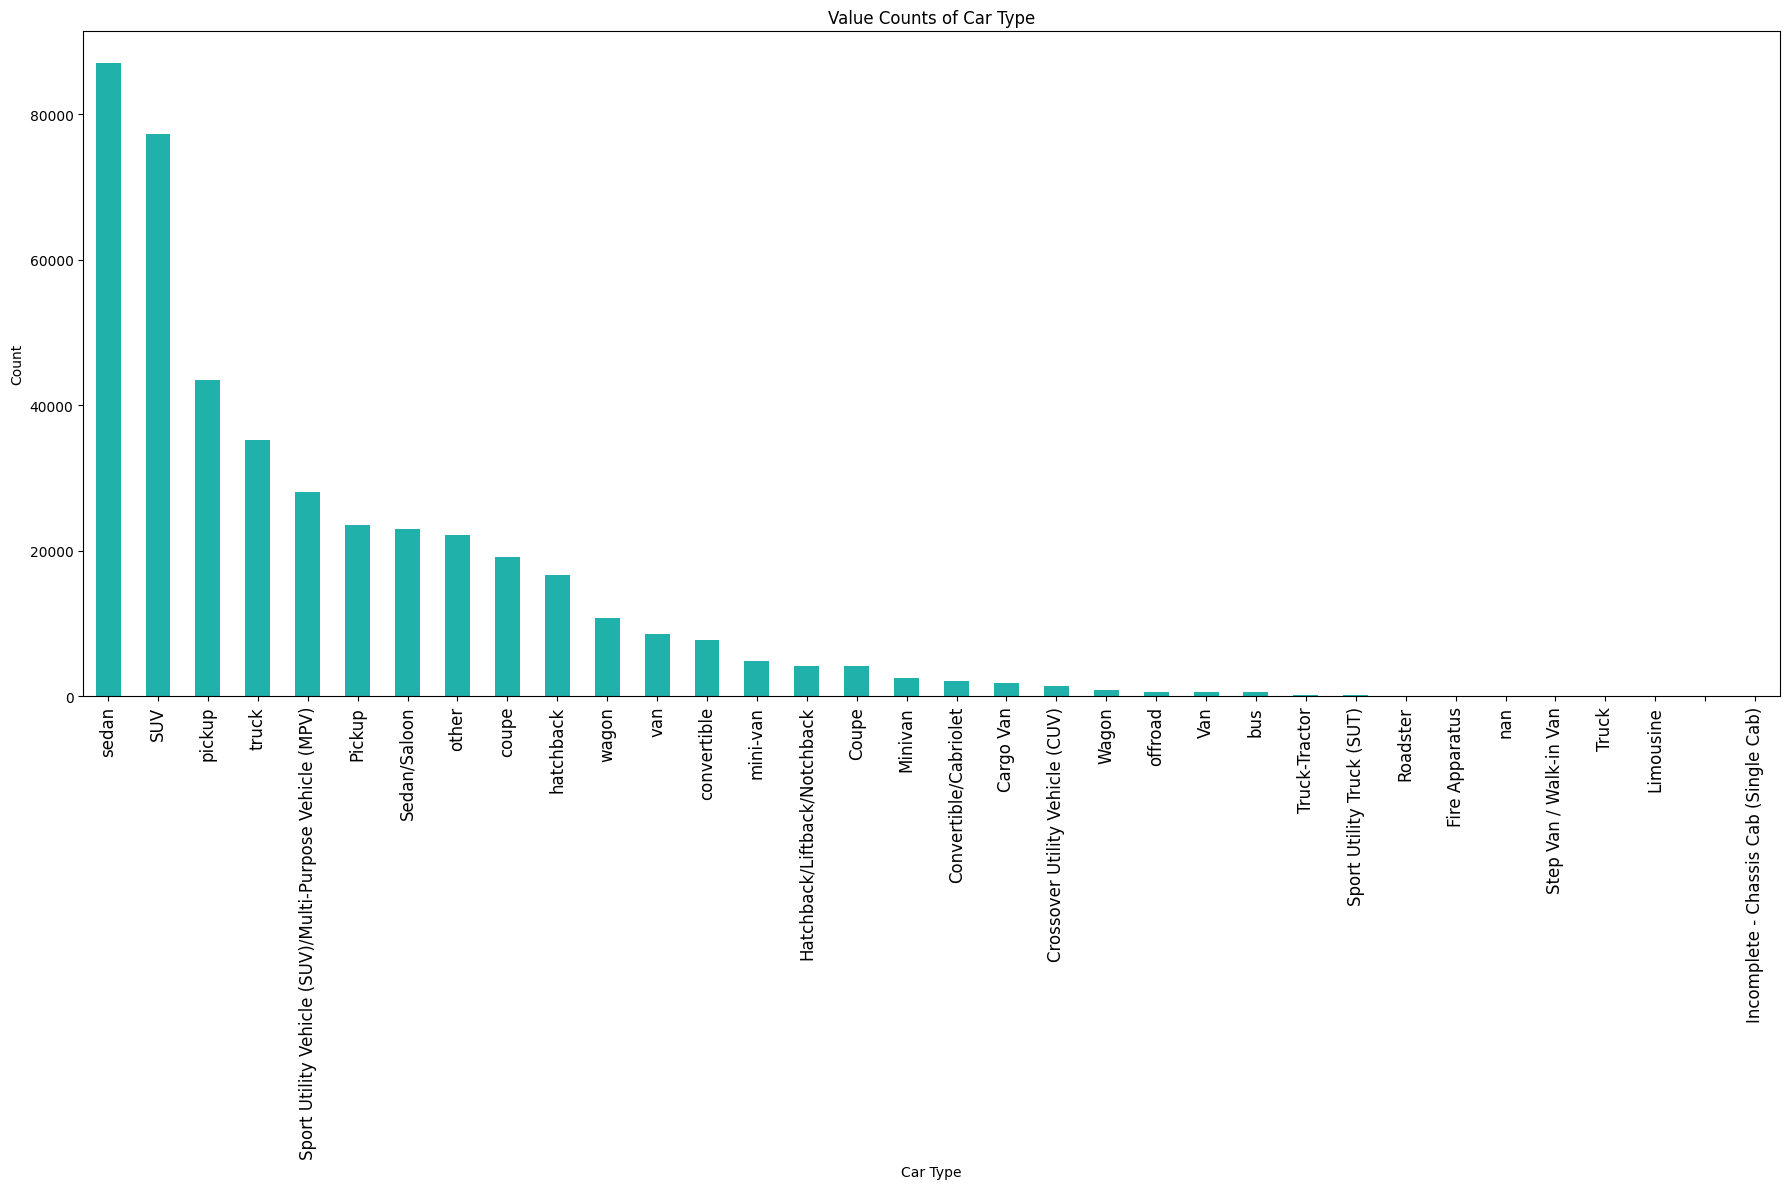

In [9]:
#Value count plot helps to merge certain categories with very low counts 
car_raw['type'].value_counts(dropna=False).plot(kind='bar', figsize=(18, 12), color='lightseagreen')
plt.title('Value Counts of Car Type')
plt.xlabel('Car Type')
plt.ylabel('Count')
plt.xticks(rotation=90, fontsize=12)
plt.tight_layout()
# Save the plot
plt.savefig("images/categories_value_counts.png")  # Saves as PNG
plt.show()

In [10]:
#Reduce distinct values of I_type where possible
replace_map = {
    'Convertible/Cabriolet': 'convertible',
    'Sport Utility Vehicle (SUV)/Multi-Purpose Vehicle (MPV)': 'SUV',
    'Sedan/Saloon': 'sedan',
    'Hatchback/Liftback/Notchback': 'hatchback',
    'Cargo Van': 'van',
    'Minivan': 'mini-van',
    'Step Van / Walk-in Van': 'van',
    'offroad': 'other',
    'Sport Utility Truck (SUT)': 'truck',
    'Fire Apparatus': 'other',
    'Incomplete - Chassis Cab (Single Cab)': 'sedan',
    'Crossover Utility Vehicle (CUV)': 'SUV'
    
}
car_raw['type'] = car_raw['type'].replace(replace_map)

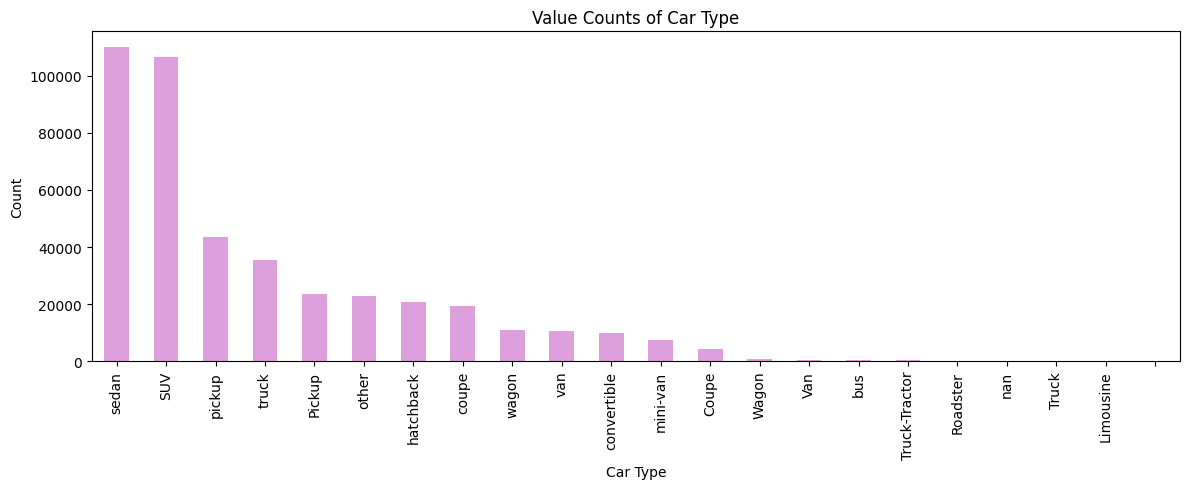

In [11]:
#Final reduced categorical values for type
car_raw['type'].value_counts(dropna=False).plot(kind='bar', figsize=(12, 5), color='plum')
plt.title('Value Counts of Car Type')
plt.xlabel('Car Type')
plt.ylabel('Count')
plt.xticks(rotation=90, fontsize=10)
plt.tight_layout()
# Save the plot
plt.savefig("images/type_value_counts.png")  # Saves as PNG
plt.show()

In [12]:
#Final distinct values of type  where possible
unique_types = car_raw['type'].unique()
print(f"Unique values in type are: {unique_types}\n")

Unique values in type are: [nan 'pickup' 'truck' 'other' 'convertible' 'coupe' 'SUV' 'hatchback'
 'mini-van' 'sedan' 'bus' 'van' 'Pickup' 'wagon' 'Van' 'Coupe' 'Truck'
 'Wagon' '' 'Roadster' 'Truck-Tractor' 'Limousine']



In [13]:
#Reduce distinct values of manufacturer  where possible
unique_types = car_raw['manufacturer'].unique()
print(f"Unique values in manufacturer are: {unique_types}\n")


Unique values in manufacturer are: [None 'gmc' 'chevrolet' 'toyota' 'ford' 'jeep' 'nissan' 'ram' 'mazda'
 'cadillac' 'honda' 'dodge' 'lexus' 'jaguar' 'buick' 'chrysler' 'volvo'
 'audi' 'infiniti' 'lincoln' 'alfa-romeo' 'subaru'
 'Toyota Motor Corporation' 'acura' 'hyundai' 'mercedes-benz'
 'Daqing Volvo Car Manufacturing Co Ltd' 'American Honda Motor Co., Inc.'
 'bmw' 'mitsubishi' 'Mercedes-Benz Cars' 'Audi AG' 'volkswagen' 'porsche'
 'kia' 'General Motors LLC' 'BMW AG' 'Maserati S.P.A.'
 'Nissan North America, Inc.' 'Suzuki Motor Of America, Inc' 'rover'
 'Toyota Motor Mfg de Baja California S de RL de CV' 'ferrari' 'mini'
 'pontiac' 'BMW Manufacturer Corporation / BMW North America'
 'Toyota Motor Manufacturing, Mississippi, Inc.' 'Ford Motor Company'
 'Honda Of Canada Mfg., Inc.' 'Chrysler De Mexico Toluca' 'fiat'
 'Jaguar Land Rover Limited' 'Hyundai Motor Co'
 'Ford Motor Company Of Canada, Ltd.'
 'Toyota Motor Manufacturing, Kentucky, Inc.' 'Dr. Ing. H.C.F. Porsche AG'
 'FCA US L

In [14]:
#Reduce distinct values of I_type where possible
replace_map = {
    'Toyota Motor Corporation': 'toyota',
    'Toyota Motor Manufacturing de Guanajuato': 'toyota',
    'Toyota Motor Manufacturing, California, Inc.': 'toyota',
    'Toyota Motor Manufacturing, Indiana, Inc.': 'toyota',
    'Toyota Motor Manufacturing, Kentucky, Inc.': 'toyota',
    'Toyota Motor Manufacturing, Mississippi, Inc.': 'toyota',
    'Toyota Motor Manufacturing, Northern Kentucky, Inc.': 'toyota',
    'Toyota Motor Manufacturing, Texas, Inc.': 'toyota',
    'Toyota Motor Manufacturing Canada': 'toyota',
    'Toyota Motor North America, Inc': 'toyota',
    'Toyota Motor Mfg de Baja California S de RL de CV': 'toyota',
    'Toyota Motor Manufacturing, France, S.A.S.': 'toyota',
    'Toyota Motor Manufacturing, Turkey ,Inc.': 'toyota',
    'Toyota Motor Mfg de Baja California S de RL de CV': 'toyota',
    'Daqing Volvo Car Manufacturing Co Ltd': 'volvo',
    'General Motors LLC': 'gmc',
    'BMW AG': 'bmw',
    'Mercedes-Benz Cars': 'mercedes-benz',
    'Audi AG': 'audi',
    'Volkswagen AG': 'volkswagen',
    'Nissan North America, Inc.': 'nissan',
    'BMW Manufacturer Corporation / BMW North America': 'bmw',
    'FCA US LLC': 'fiat',
    'Mazda Motor Corporation': 'mazda',
    'Honda Of Canada Mfg., Inc.': 'honda',
    'Hyundai Motor Co': 'hyundai',
    'Ford Motor Company': 'ford',
    'Mitsubishi Motors Corporation (MMC)': 'mitsubishi',
    'Porsche': 'porsche',
    'Kia Corporation': 'kia',
    'Tesla, Inc.': 'tesla',
    'Volvo Car Corporation': 'volvo',
    'Kia Georgia, Inc': 'kia',
    'Saab Cars North America, Inc.': 'saab',
    'Hyundai-Kia America Technical Center Inc (HATCI)': 'hyundai',
    'Alfa Romeo S.P.A.': 'alfa-romeo',
    'Maserati S.P.A.': 'maserati',
    'Jaguar Land Rover Limited': 'jaguar',
    'Ferrari S.P.A.': 'ferrari',
    'Lamborghini SPA': 'ferrari',
    'Bentley Motors Limited': 'bentley',
    'Rolls Royce Motor Cars': 'rolls-royce',
    'Nissan Motor Company, Ltd': 'nissan',
    'Honda Motor Co., Ltd': 'honda',
    'Land Rover': 'land rover',
    'Isuzu Motors Limited, Japan': 'isuzu',
    'Honda Of The U.K. Mfg., Ltd.': 'honda',
    'Subaru Of America, Inc': 'subaru',
    'Suzuki Motor Of America, Inc': 'suzuki',
    'Rover': 'rover',
    'Ferrari': 'ferrari',
    'Mini': 'mini',
    'Pontiac': 'pontiac',
    'Chrysler De Mexico Toluca': 'chrysler',
    'Fiat': 'fiat',
    'Ford Motor Company Of Canada, Ltd.': 'ford',
    'Dr. Ing. H.C.F. Porsche AG': 'porsche',
    'Saturn': 'saturn',
    'Mercury': 'mercury',
    'Sterling Trucks (Daimler Division)': 'sterling',
    'Bentley': 'bentley',
    'Volkswagen De Mexico Sa De Cv': 'volkswagen',
    'Volvo Car USA, LLC': 'volvo',
    'FCA Italy S.P.A.': 'fiat',
    'Subaru Corporation': 'subaru',
    'Ford Motor Company, Mexico': 'ford',
    'FCA Canada Inc.': 'fiat',
    'Saab': 'saab',
    'Western Star Trucks Inc': 'western-star',
    'Harley-Davidson': 'harley-davidson',
    'Isuzu': 'isuzu',
    'Automobili Lamborghini SPA': 'lamborghini',
    'Mazda Motor Manufacturing De Mexico S.A. De C.V.': 'mazda',
    'Ford Otomotiv Sanayi A.S., Turkey': 'ford',
    'Kenworth Truck Company': 'kenworth',
    'Nissan Mexicana, S.A. De C.V.': 'nissan',
    'Renault Samsung Motors Co., Ltd': 'renault',
    'Am General LLC': 'am-general',
    'Auto Alliance International, USA': 'auto-alliance',
    'Datsun': 'datsun',
    'Honda De Mexico': 'honda',
    'Karma Automotive LLC': 'karma',
    'Fisker Automotive, Inc.': 'fisker',
    'New United Motor Manufacturing, Inc.': 'new-united-motor',
    'Peterbilt Motors Company': 'peterbilt',
    'Mercedes-Benz, AG': 'mercedes-benz',
    'Volkswagen Group Of America, Inc.': 'volkswagen',
    'Mercedes-Benz Of North America, Inc.': 'mercedes-benz',
    'Kia Mexico S.A. De C.V.': 'kia',
    'Daimler Truck North America LLC': 'daimler',
    'Nissan Motor Manufacturing (Uk) Ltd': 'nissan',
    'Adam Opel AG': 'opel',
    'Lotus Cars Ltd.': 'lotus',
    'Audi Sport GmbH': 'audi',
    'BMW M Gmbh': 'bmw',
    'Aston-Martin': 'aston-martin',
    'Ford India Ltd': 'ford',
    'Daimler Chrysler AG': 'daimler',
    'Rolls Royce Motor Cars': 'rolls-royce',
    'Land Rover': 'land rover',
    'Tabc Inc.': 'tabc',
    'The Vehicle Production Group LLC': 'vehicle-production-group',
    'Mack Trucks Inc.': 'mack',
    'Mitsubishi Motors North America': 'mitsubishi',
    'Navistar, Inc.': 'navistar',
    'Hyundai Motor Manufacturing Alabama LLC (Hmma)': 'hyundai',
    'Jac Milwaukee, Ltd.': 'jac',
    'Chrysler Group LLC(USA),Chrysler Canada, Chrysler De Mexico': 'chrysler',
    'Sanfu Motor Industry': 'sanfu',
    'Mclaren Automotive Limited': 'mclaren',
    'Ford Werke AG': 'ford',
    'Pierce Manufacturing Inc.': 'pierce',
    'Morgan': 'morgan',
    'Navistar Canada, Inc.': 'navistar',
    'Cami Automotive Inc': 'cami',
    'E-One, Inc.': 'e-one',
    'Daimler Chrysler De Mexico Sa De Cv': 'daimler',
    'Avanti Motor Corporation': 'avanti',
    'Workhorse Custom Chassis': 'workhorse',
    'Volvo Group North America, LLC': 'volvo',
    'Blue Diamond Truck, S. De R. L. De C. V.': 'blue-diamond-truck',
    'Coda Automotive, Inc.': 'coda',
    'Fuji Heavy Industries U.S.A., Inc. (C/O Subaru Of America)': 'subaru'
}
car_raw['manufacturer'] = car_raw['manufacturer'].replace(replace_map)

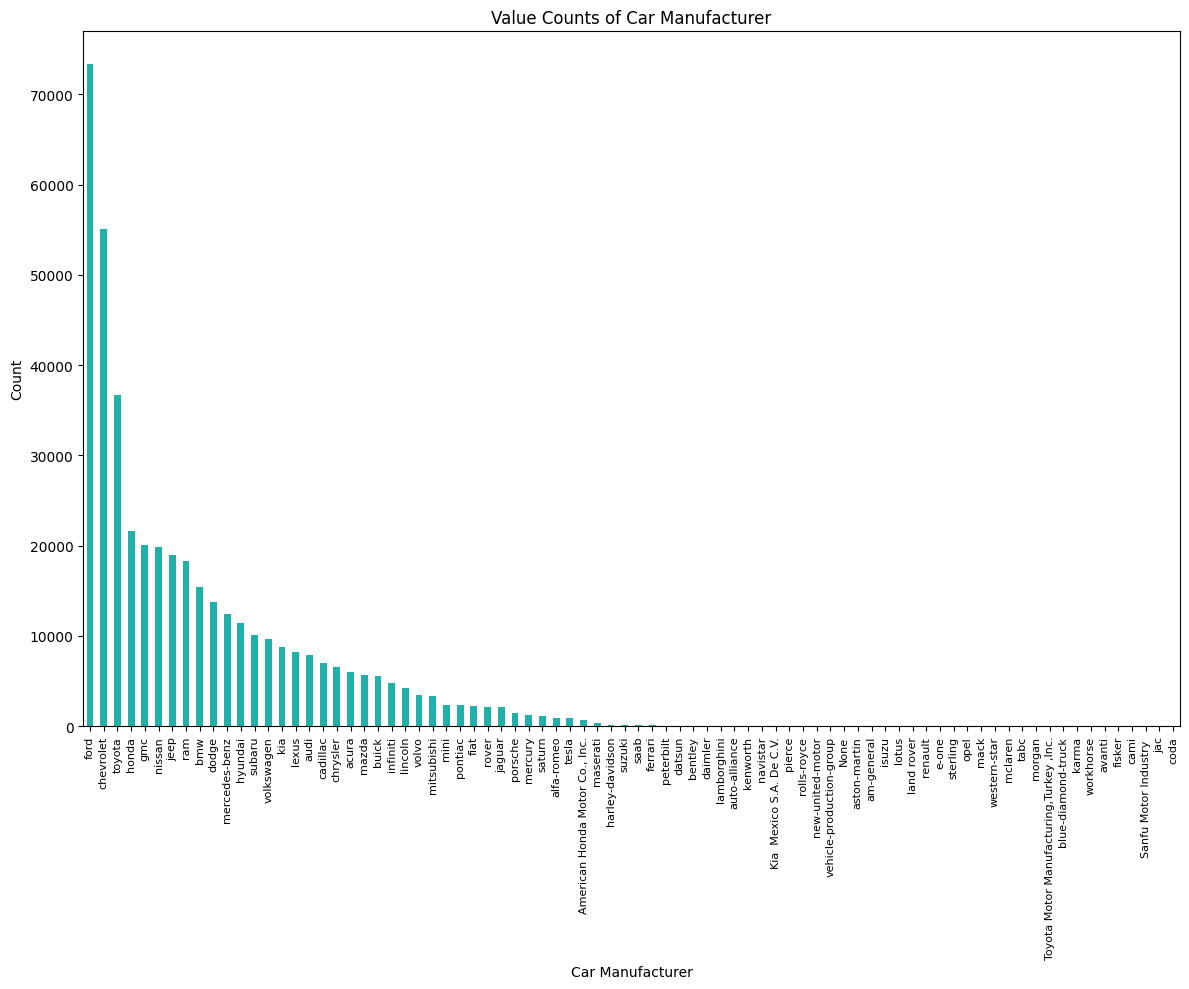

In [15]:
#Final reduced categorical values for type
car_raw['manufacturer'].value_counts(dropna=False).plot(kind='bar', figsize=(12, 10), color='lightseagreen')
plt.title('Value Counts of Car Manufacturer')
plt.xlabel('Car Manufacturer')
plt.xticks(rotation=90, fontsize=8)
plt.ylabel('Count')

plt.tight_layout()
# Save the plot
plt.savefig("images/manufacturer_value_counts.png")  # Saves as PNG
plt.show()

In [16]:
#car_temp=pd.read_csv('/Users/ppeethambaran/Desktop/practical_application_II_starter/data/vehicles.csv')
unique_types = car_raw['I_model'].unique()
print(f"Unique values in I_model are: {unique_types}\n")

#based on cleaner values in I_model will retain it and drop model
car_raw = car_raw.drop([ 'model' ], axis=1)

Unique values in I_model are: [None 'Sierra' 'Silverado' 'Tundra' 'Colorado' 'Corvette' 'Wrangler'
 'Tacoma' 'Camaro' 'Ranger' 'Frontier' 'F-150' '1500' 'MX-5' 'XT4'
 'Renegade' 'Mustang' 'Silverado LD' 'Civic' 'Expedition' 'NX' 'E-PACE'
 'Encore GX' 'S60 Cross Country' 'S60' 'Q5' 'QX60' 'Continental' 'Stelvio'
 'Scion iM' 'MDX' 'A6' 'Sonata' 'Sierra Limited' 'F-250' 'Wrangler JK'
 'Acadia' 'MKZ' 'Express' 'Camry' '128i' '300' 'Outlander Sport' 'Sentra'
 'Fortwo' 'Titan' 'XT5' 'FJ Cruiser' 'Altima' 'Enclave' 'Sierra HD' '535i'
 'Optima' 'LaCrosse' 'Echo' 'Elantra' '525i' 'C-Max' 'Canyon' 'G35'
 'Levante' 'Corolla' 'Soul' 'Kicks' 'Sorento' 'Pathfinder' 'Cayman' 'SRX'
 'Grand Vitara XL-7' 'X3' 'STS' 'TL' 'Murano' 'Avalon' 'LeSabre' 'Edge'
 'Terrain' 'Captiva Sport' 'Forte Koup' 'Cobalt' 'Grand Caravan'
 'ML-Class' 'Rogue Sport' 'QX30' 'Legacy' 'Ram' 'Grand Cherokee'
 'Cavalier' 'Traverse' 'Charger' 'Pilot' 'Regal' 'Elantra Touring' 'Forte'
 'JX35' 'Yukon XL' 'Sportage' 'Accent' '360 Spid

/var/folders/73/9j149hs9505dw9fxc__snb1h0000gn/T/ipykernel_16833/1495233178.py:9: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


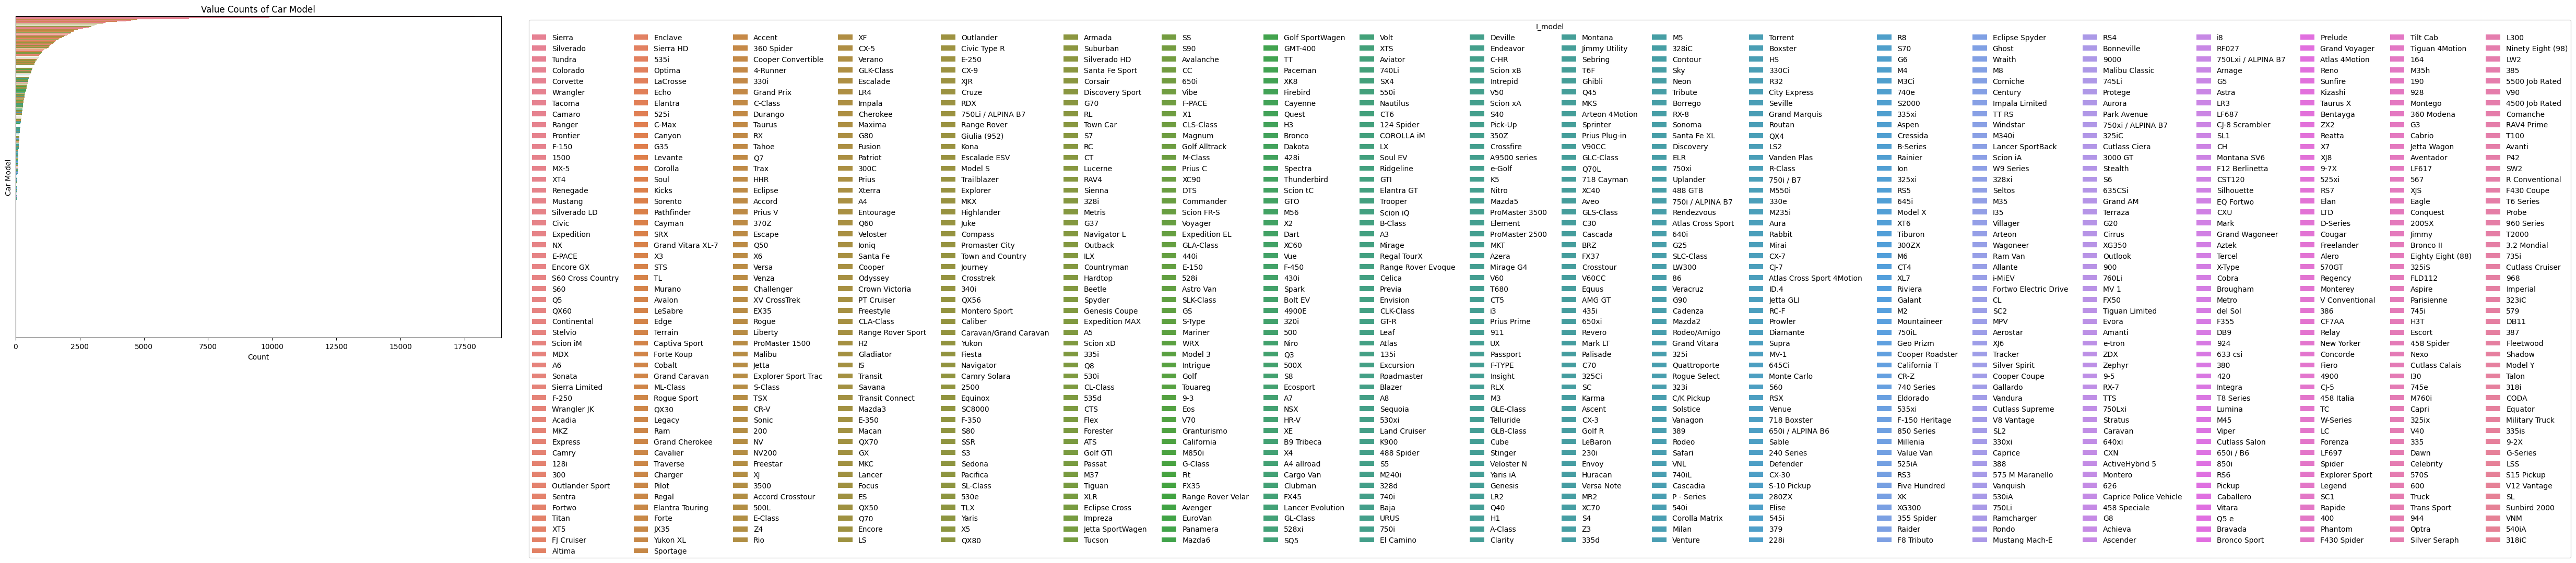

In [17]:
#Final reduced categorical values for type
plt.figure(figsize=(12, 8))
sns.countplot(data=car_raw, y='I_model', order=car_raw['I_model'].value_counts().index,hue='I_model')
plt.title('Value Counts of Car Model')
plt.xlabel('Count')
plt.ylabel('Car Model')
plt.yticks([]) 
plt.legend(title='I_model', bbox_to_anchor=(1.05, 1), loc='upper left', ncol=20)
plt.tight_layout()
# Save the plot
plt.savefig("images/model_value_counts.png")  # Saves as PNG
plt.show()

---
#### 2.2 Feature Engineering / Data Transformation

<span style="color:black">1. Extract Age of Car</span>  
&nbsp;&nbsp;&nbsp;&nbsp;- Calculate age from the `year` column (e.g., current year - car year)  

<span style="color:black">2. Convert String Cylinders to Float</span>  
&nbsp;&nbsp;&nbsp;&nbsp;- Clean and convert values like `'6 cylinders'` → `6.0`  

<span style="color:blcak">3. Assign 0 Cylinders for Electric Cars</span>  
&nbsp;&nbsp;&nbsp;&nbsp;- If `fuel == 'electric'`, set `cylinders = 0` 

---

In [18]:
# Calculate age based on the current year  
current_year = 2025
car_raw['I_age'] = current_year - car_raw['year']

In [19]:
#Convert all cylinders values to int and electric motors to 0 , thne imputate the others values
car_raw['I_cylinders'] = car_raw['cylinders'].apply(lambda x: float(str(x).split()[0]) if pd.notna(x) and str(x) != 'other' else np.nan)
car_raw.loc[car_raw['fuel'] == 'electric', 'I_cylinders'] = 0 

---
### 2.2 Calculate the James-Stein Estimator for 'Cylinders' within Each Group

In this section, we apply the James-Stein estimator to the 'cylinders' feature within different groups. The James-Stein estimator is a statistical method used to improve the estimation of group means by shrinking the estimates towards a global mean, which helps reduce the overall variance.

The steps involved are:

1. **Group the data**: We group the dataset by a categorical variable (e.g., `manufacturer`,`model`) and calculate the mean and variance of the 'cylinders' feature for each group.
2. **Calculate the global mean** of the 'cylinders' feature across all groups.
3. **Apply the James-Stein estimator**:
   - The estimator adjusts the group mean towards the global mean based on the sample size and variance.
   - The formula for the James-Stein estimator is:
   
   \[
   \hat{\mu}_{JS} = \bar{x} + \left( 1 - \frac{(n-3) \cdot s^2}{(n-1) \cdot \sum_{i=1}^{n} (x_i - \bar{x})^2} \right) \cdot (\mu - \bar{x})
   \]
   
   Where:
   - \(\bar{x}\) is the sample mean of the group,
   - \(s^2\) is the sample variance of the group,
   - \(n\) is the number of samples in the group,
   - \(\mu\) is the overall mean across all groups.
   
4. **Return the James-Stein estimates**: After applying the estimator to each group, we add the adjusted values back to the original dataset for further analysis.

This method helps improve the accuracy of group mean estimates, particularly when there are small sample sizes or high variability within groups.

---

In [20]:
# Calculate the James-Stein estimator for 'cylinders' within each group

grouped = car_raw.groupby(['I_model', 'manufacturer'])['I_cylinders']

def james_stein_estimator(group):
    n = len(group)
    if n <= 1 :
        return group
    mean = group.mean()
    variance = group.var()
    
    # Check if variance is zero to avoid division by zero.
    if variance == 0 :
        return group
    
    shrinkage_factor = max(0, 1 - ( (len(group) - 3) * variance / (mean**2) ) ) #added a check to avoid negative shrinkage factor
    
    # Apply the James-Stein estimator
    estimated_values = (1 - shrinkage_factor) * mean + shrinkage_factor * group.mean()
    return estimated_values

car_raw['cylinders_js'] = grouped.transform(james_stein_estimator)

# Replace missing 'cylinders' values with the James-Stein estimates
car_raw['I_cylinders'].fillna(car_raw['cylinders_js'], inplace=True)

# Drop the temporary 'cylinders_js' column
car_raw = car_raw.drop(columns=['cylinders_js'])

In [21]:
# Calculate the James-Stein estimator for 'odometer' within each group based on year and condition 
car_raw['I_odometer']=car_raw['odometer']
grouped = car_raw.groupby(['I_age', 'condition'])['odometer']
car_raw['odometer_js'] = grouped.transform(james_stein_estimator)

# Replace missing 'cylinders' values with the James-Stein estimates
car_raw['I_odometer'].fillna(car_raw['odometer_js'], inplace=True)
car_raw['I_cylinders']=round(car_raw['I_cylinders'])

# Drop the temporary 'cylinders_js' column
car_raw = car_raw.drop(columns=['odometer_js'])

/var/folders/73/9j149hs9505dw9fxc__snb1h0000gn/T/ipykernel_16833/810324353.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  car_raw['I_odometer'].fillna(car_raw['odometer_js'], inplace=True)


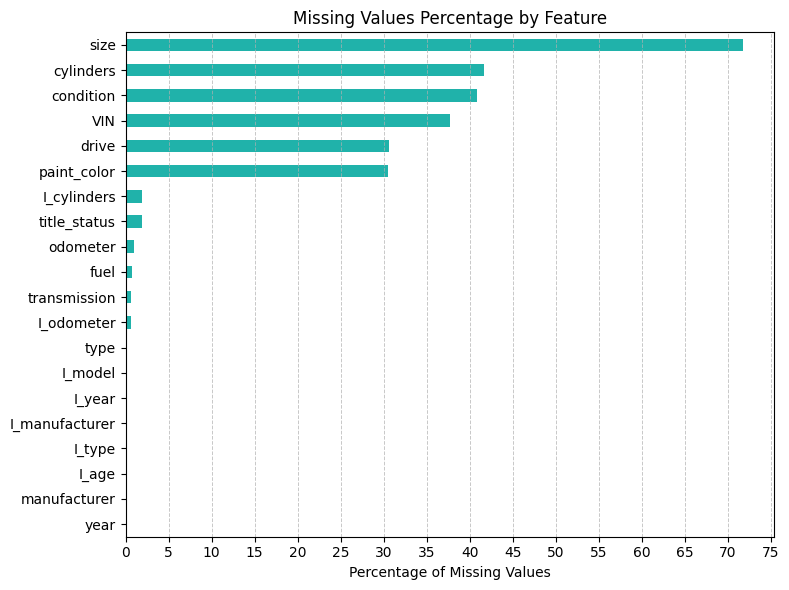

In [22]:
#Backup dont run in regular flow
#car_raw=car_raw_vin
null_percent = car_raw.isnull().mean() * 100
null_percent = null_percent[null_percent > 0].sort_values(ascending=True)
max_percent = null_percent.max()
# Plot
plt.figure(figsize=(8, 6))
null_percent.plot(kind='barh', color='lightseagreen')
plt.xlabel('Percentage of Missing Values')
plt.title('Missing Values Percentage by Feature')
plt.xticks(np.arange(0, max_percent + 5, 5))
plt.grid(axis='x', linestyle='--', linewidth=0.7, alpha=0.7)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

###  📊 2.3 Outlier Treatment

Outliers in numerical columns such as `price` and `odometer` were identified using the **Interquartile Range (IQR)** method. This statistical approach helps detect values that fall significantly outside the typical range.

- 🔍 **Detection**:  
  Values below `Q1 - 1.5 * IQR` or above `Q3 + 1.5 * IQR` were flagged as outliers.

- 🔁 **Replacement Strategy**:  
  Instead of removing these records, which could lead to loss of valuable data, we **replaced outlier values with the column median**. This approach preserves dataset size and reduces the influence of extreme values.

- 📈 **Transparency**:  
  The number of outliers replaced was logged for each column, ensuring traceability and accountability in preprocessing.

In [23]:
# Replace outliers with median using IQR, with custom handling for 'odometer'
def replace_outliers_with_median_custom(df, columns):
    df_cleaned = df.copy()
    
    for col in columns:
        Q1 = df_cleaned[col].quantile(0.25)
        Q3 = df_cleaned[col].quantile(0.75)
        IQR = Q3 - Q1
        #print(col,Q1,Q3)

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        #print(col,lower_bound,upper_bound)
        median_value = df_cleaned[col].median()

        if col == 'odometer':
            # Only replace values greater than upper bound
            outliers = df_cleaned[col] > upper_bound
        else:
            # Replace values outside IQR range
            outliers = (df_cleaned[col] < lower_bound) | (df_cleaned[col] > upper_bound) | (df_cleaned[col] == 0)
        
        num_outliers = outliers.sum()
        df_cleaned.loc[outliers, col] = median_value

        print(f"✅ Replaced {num_outliers} outliers in '{col}' with median value {median_value:.2f}")
    
    return df_cleaned

# Columns to clean
cols_to_clean = ['price', 'odometer']
car_raw = replace_outliers_with_median_custom(car_raw, cols_to_clean)

✅ Replaced 41072 outliers in 'price' with median value 13950.00
✅ Replaced 4385 outliers in 'odometer' with median value 85548.00


In [24]:
'''# Filter cars with price under 1000
cheap_cars = car_raw[(car_raw['price'] < 1000) & (car_raw['odometer']<1000) & (car_raw['I_condition']<2)&(car_raw['I_title_status']<4)]
cheap_cars1 = car_raw[(car_raw['price'] < 1000) & (car_raw['odometer']<37704) & (car_raw['I_age']<6) &   ((car_raw['I_condition']>1)|(car_raw['I_title_status']>3))]
# Value counts for condition and title status
print("🔍 Condition distribution for cars priced under $1000:")
print(cheap_cars1['I_condition'].value_counts(dropna=False))

print("\n🔍 Title status distribution for cars priced under $1000:")
print(cheap_cars1['I_title_status'].value_counts(dropna=False))'''

'# Filter cars with price under 1000\ncheap_cars = car_raw[(car_raw[\'price\'] < 1000) & (car_raw[\'odometer\']<1000) & (car_raw[\'I_condition\']<2)&(car_raw[\'I_title_status\']<4)]\ncheap_cars1 = car_raw[(car_raw[\'price\'] < 1000) & (car_raw[\'odometer\']<37704) & (car_raw[\'I_age\']<6) &   ((car_raw[\'I_condition\']>1)|(car_raw[\'I_title_status\']>3))]\n# Value counts for condition and title status\nprint("🔍 Condition distribution for cars priced under $1000:")\nprint(cheap_cars1[\'I_condition\'].value_counts(dropna=False))\n\nprint("\n🔍 Title status distribution for cars priced under $1000:")\nprint(cheap_cars1[\'I_title_status\'].value_counts(dropna=False))'

In [25]:
#Drop Na for model,manufacturer, age,year,cylinders,odometer
car_raw = car_raw.dropna(subset=['I_model','type', 'manufacturer','I_age','year','I_cylinders','I_odometer','fuel','title_status','transmission'])

#Drop the temporary coulmns and columns with large missing values aka Size , id
car_raw = car_raw.drop(['year', 'I_manufacturer','VIN','cylinders', 'odometer','I_type','size','id'], axis=1)


##Impute values for condiiton but does not make any difference
#title_list = ['salvage', 'parts only', 'missing' ]
#car_raw.loc[car_raw['title_status'].isin(title_list), 'condition'] = 'salvage'

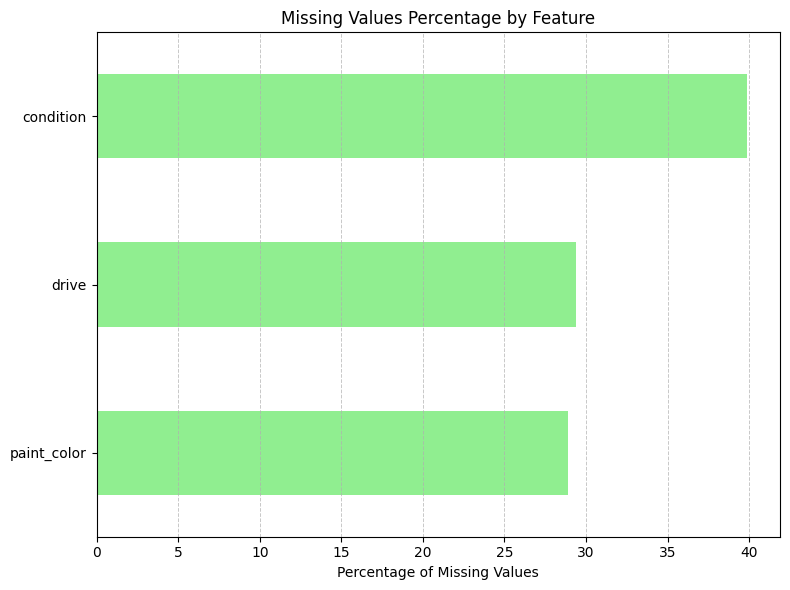

In [26]:

null_percent = car_raw.isnull().mean() * 100
null_percent = null_percent[null_percent > 0].sort_values(ascending=True)
max_percent = null_percent.max()
# Plot
plt.figure(figsize=(8, 6))
null_percent.plot(kind='barh', color='lightgreen')
plt.xlabel('Percentage of Missing Values')
plt.title('Missing Values Percentage by Feature')
plt.xticks(np.arange(0, max_percent + 5, 5))
plt.grid(axis='x', linestyle='--', linewidth=0.7, alpha=0.7)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
# Save the plot
plt.savefig("images/last_few_missing.png")  # Saves as PNG
plt.show()

---
### 2.4 Encode 'condition' and 'title_status' as Ordinal

In this step, we will encode the `condition` and `title_status` columns as **ordinal** variables. Ordinal encoding is suitable for categorical variables where there is a natural order or ranking.

- **Condition**: The `condition` feature typically indicates the quality or state of the car. It follows a natural order, such as:
  - Excellent
  - Good
  - Fair
  - Poor

- **Title Status**: The `title_status` feature represents the ownership and history of the car, and it also has a meaningful order, such as:
  - Clean
  - Salvage
  - Lien

For ordinal encoding, we assign integer values to these categories based on their inherent order.

##### Encoding Strategy:
- **Condition**: The values are mapped as follows:
  - New = 6
  - Like new = 5
  - Excellent = 4
  - Good = 3
  - Fair = 2
  - Salvage = 1
- **Title Status**: The values are mapped as follows:
  - Clean = 6
  - Lien = 5
  - rebuilt = 4
  - salvage = 3
  - parts only = 2
  - missing =1

---


In [27]:

# Encode 'condition' as ordinal
condition_order = ['salvage','fair','good', 'excellent', 'like new', 'new' ]

#Encode condition (leave NaNs as is, use OrdinalEncoder)
condition_encoder = OrdinalEncoder(categories=[condition_order], handle_unknown='use_encoded_value', unknown_value=-1)
car_raw['I_condition'] = condition_encoder.fit_transform(car_raw[['condition']])
car_raw = car_raw.drop(['condition'], axis=1)

In [28]:
# Encode condition title_status
title_status_order=['missing','parts only','salvage','rebuilt','lien','clean']
#car_raw['title_status_filled'] = car_raw['title_status'].fillna('nodata')

title_encoder = OrdinalEncoder(categories=[title_status_order],handle_unknown='use_encoded_value', unknown_value=-1)
car_raw['I_title_status'] = title_encoder.fit_transform(car_raw[['title_status']])
car_raw = car_raw.drop(['title_status'], axis=1)

---
### 🔄  2.4 Encoding Strategy: Iterative Refinement for Model Improvement

To improve model accuracy (initial **R² ≈ 0.56**), we applied an **iterative feature encoding approach**, focusing on more efficient representations of categorical data. One major step was transforming certain features from **one-hot encoding to ordinal encoding** where appropriate:

#### 🧩 Step: Drive Type Encoding
#### 🧩 Step: Drive Type Encoding

Originally, the `drive` feature was **one-hot encoded** as:

- `drive_fwd`, `drive_rwd`, `drive_4wd`, `drive_nan`

This added multiple sparse binary columns, which might not be optimal for polynomial or distance-based models.

To simplify and capture **implicit ordinal relationships**, we converted the feature into a **single ordinal column**, reflecting a hierarchy based on traction/performance relevance:

| Drive Type | Ordinal Code |
|------------|--------------|
| fwd        |  1            |
| rwd        |  2            |
| 4wd        |  3            |
| NaN/Other  | -1            |

#### ✅ Benefits Observed

- Reduced dimensionality
- Captured **drive hierarchy** (e.g., 4WD often in more expensive vehicles)
- Decreased **model performance**, pushing R² **below 0.56**
- R² only dropped ~0.0133: That’s about a 1.3% decrease in the explained variance.
- Traded off interpretability or dimensionality can be helpful for simpler or faster models.

---

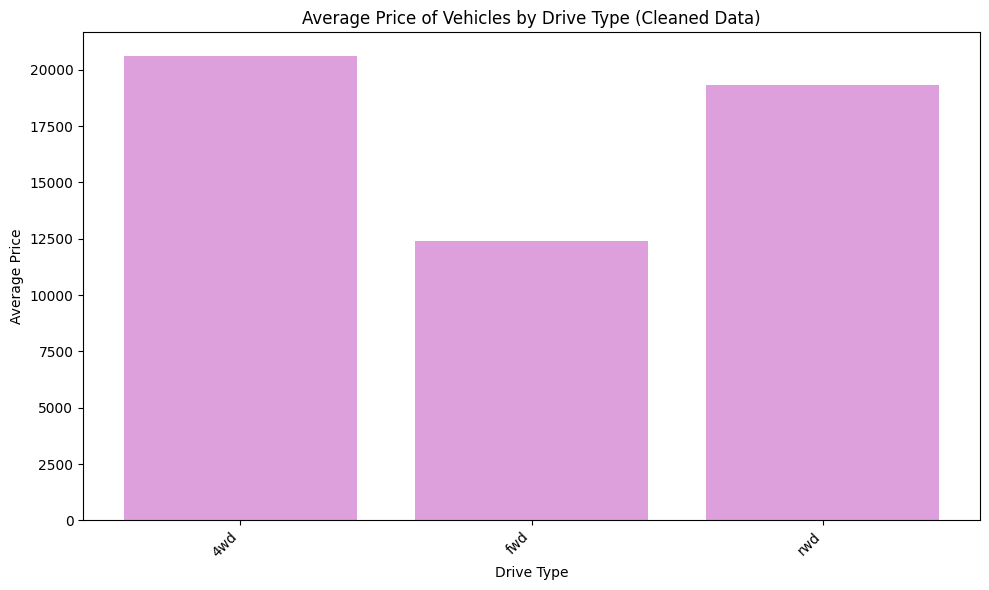

In [29]:
# Calculate the average price for each drive type
avg_price_by_drive = car_raw .groupby('drive')['price'].mean()

# Create the bar plot
plt.figure(figsize=(10, 6))
plt.bar(avg_price_by_drive.index, avg_price_by_drive.values ,color='plum')
plt.xlabel("Drive Type")
plt.ylabel("Average Price")
plt.title("Average Price of Vehicles by Drive Type (Cleaned Data)")
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
# Save the plot
plt.savefig("images/drive_ordinal_reason.png")  # Saves as PNG
plt.show()


In [30]:
# Encode  drive as ordinal
drive_order=['fwd','rwd','4wd']
#car_raw['title_status_filled'] = car_raw['title_status'].fillna('nodata')

title_encoder = OrdinalEncoder(categories=[drive_order],handle_unknown='use_encoded_value', unknown_value=-1)
car_raw['I_drive'] = title_encoder.fit_transform(car_raw[['drive']])
car_raw = car_raw.drop(['drive'], axis=1)

In [31]:
# One hot Encode for transmission
car_raw = pd.get_dummies(car_raw, columns=['transmission'], prefix='trans', dummy_na=True,dtype=int)
car_raw = pd.get_dummies(car_raw, columns=['fuel'] , dummy_na=True,dtype=int)
#car_raw = pd.get_dummies(car_raw, columns=['drive'] , dummy_na=True,dtype=int)
#car_raw = pd.get_dummies(car_raw, columns=['type'] , dummy_na=True,dtype=int)
#car_raw = pd.get_dummies(car_raw, columns=['paint_color'] , dummy_na=True)

---
#### 🎯 2.5 Step: James–Stein Encoding for High Cardinality

To handle categorical features with many categories but limited predictive power:

- `paint_color`
- `type`

We applied **James–Stein encoding**, which balances category-specific mean encoding with global mean, reducing overfitting risk and dimensionality:

> 🔍 This strategy preserves predictive signals while avoiding noise from rare categories.

---

In [32]:
#Use James_stien Encoder for 'paint_color' due to large number of category values to reduce dimensionality
import category_encoders as ce


# Step 1: Separate the target variable and features
target = 'price'
X = car_raw.drop(columns=[target])  # Features
y = car_raw[target]  # Target

cat_features = ['paint_color', 'state', 'manufacturer', 'I_model', 'region','type']
X[cat_features] = X[cat_features].fillna('Unknown') 

# Step 3: Initialize the JamesSteinEncoder
encoder = ce.JamesSteinEncoder(cols=cat_features)

# Step 4: Fit the encoder and transform the 'paint_color' column based on the target variable
X_encoded = encoder.fit_transform(X, y)

# Step 5: Combine the transformed columns back into the original data
car_raw_encoded = X_encoded.copy()  # This will have the encoded 'paint_color' column

# If you want to include other features (columns) besides 'paint_color', just assign back to car_raw_encoded
car_raw_encoded[target] = y



---
#### 2.5 Feature Engineering : Adding feature like age of car , mileage used per year ,ratio of price to odometer reading

---

In [33]:
#Addding a feature milage per year 

car_raw_encoded['mileage_per_year'] = car_raw_encoded['I_odometer'] / car_raw_encoded['I_age']
car_raw_encoded['price_per_mile'] = car_raw_encoded['price'] / car_raw_encoded['I_odometer'].replace(0, 1)

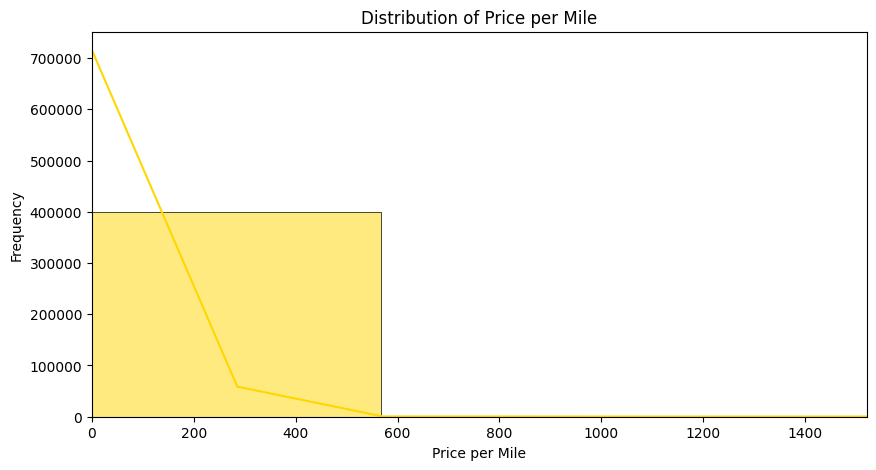

In [34]:
# Set plot style
plt.figure(figsize=(10, 5))
sns.histplot(car_raw_encoded['price_per_mile'], bins=100, kde=True ,color='gold')

# Labels and title
plt.title('Distribution of Price per Mile')
plt.xlabel('Price per Mile')
plt.ylabel('Frequency')

plt.xlim(0, car_raw_encoded['price_per_mile'].quantile(0.99))  # Limit x-axis to avoid extreme outliers
plt.show()

In [35]:
car_raw_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 405334 entries, 27 to 426879
Data columns (total 26 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   region            405334 non-null  float64
 1   manufacturer      405334 non-null  float64
 2   type              405334 non-null  float64
 3   paint_color       405334 non-null  float64
 4   state             405334 non-null  float64
 5   I_model           405334 non-null  float64
 6   I_year            405334 non-null  float64
 7   I_age             405334 non-null  float64
 8   I_cylinders       405334 non-null  float64
 9   I_odometer        405334 non-null  float64
 10  I_condition       405334 non-null  float64
 11  I_title_status    405334 non-null  float64
 12  I_drive           405334 non-null  float64
 13  trans_automatic   405334 non-null  int64  
 14  trans_manual      405334 non-null  int64  
 15  trans_other       405334 non-null  int64  
 16  trans_nan         405334

---
### 🔥 2.6 Correlation Heatmap of `car_raw_encoded`

To gain insights into relationships among variables in the dataset, we generated a **correlation heatmap**. This visual representation highlights how strongly each feature correlates with others, particularly the target variable `price`.

- **Dark blue/red cells** indicate strong correlations (positive or negative).
- **Lighter shades** indicate weaker relationships.
- This helps identify key features that might drive car prices (e.g., `I_year`, `I_odometer`, or specific encoded categorical variables).

The plot also aids in:
- Feature selection for modeling.
- Detecting multicollinearity.
- Understanding overall data structure.

We used absolute values to sort and annotate the top correlations, both positively and negatively associated with price.

---

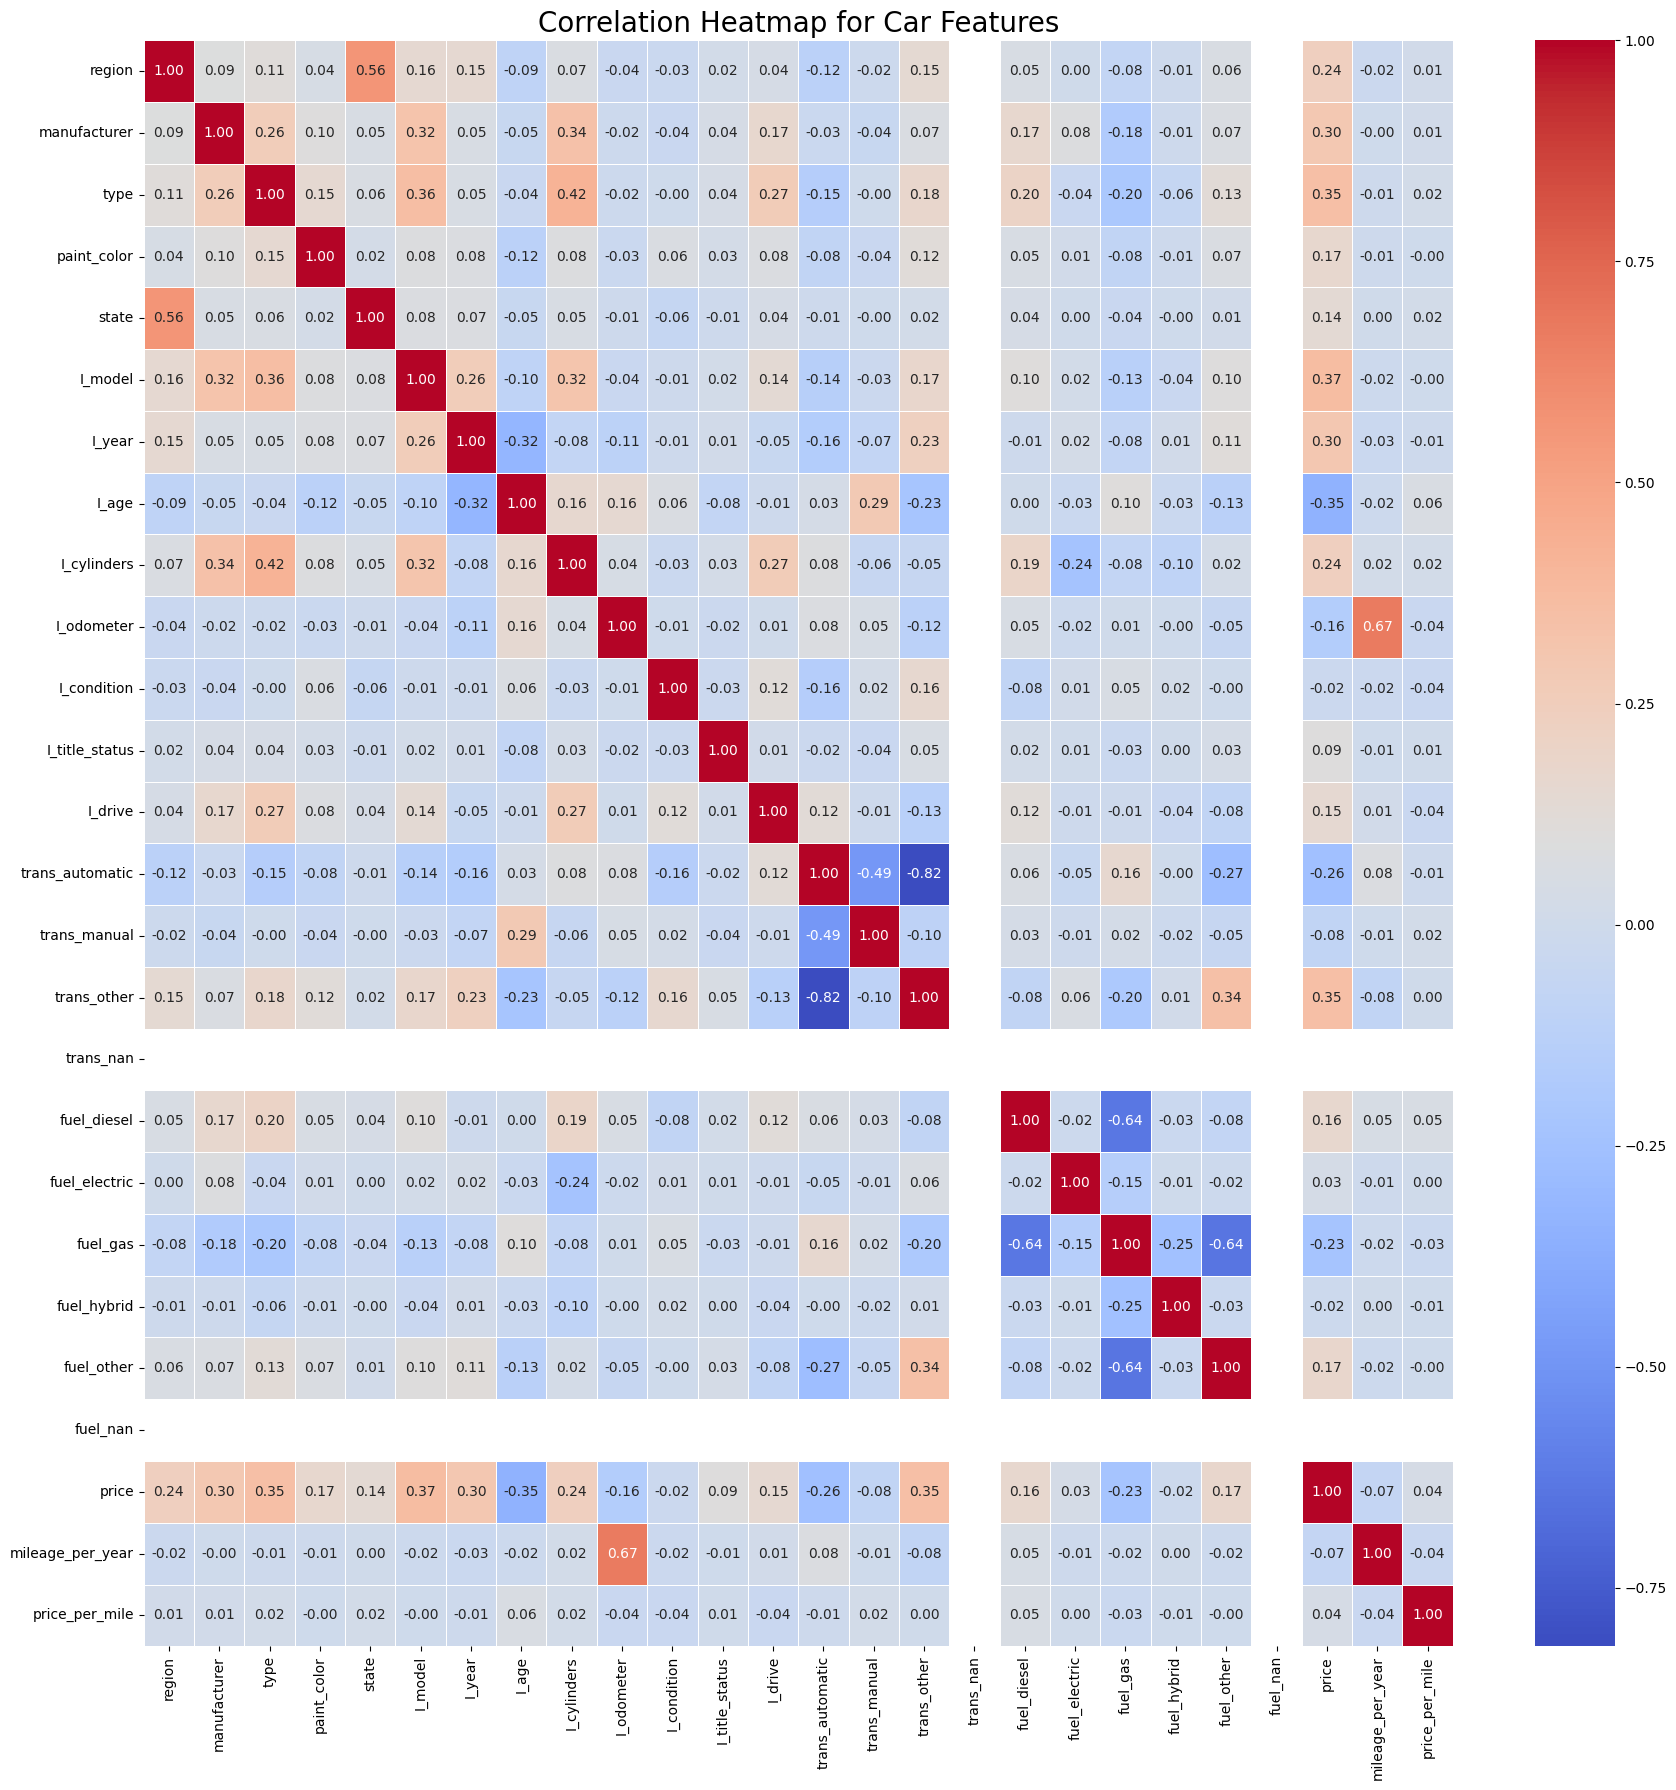

In [36]:
corr_matrix = car_raw_encoded.corr()  # Calculate correlation matrix

# Create a heatmap
plt.figure(figsize=(18, 18))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap for Car Features',fontsize=20)
plt.tight_layout()
plt.savefig("images/car_encoded_corr.png")  # Saves as PNG
plt.show()

/var/folders/73/9j149hs9505dw9fxc__snb1h0000gn/T/ipykernel_16833/2964264582.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


<Axes: xlabel='Feature', ylabel='Correlation with Price'>

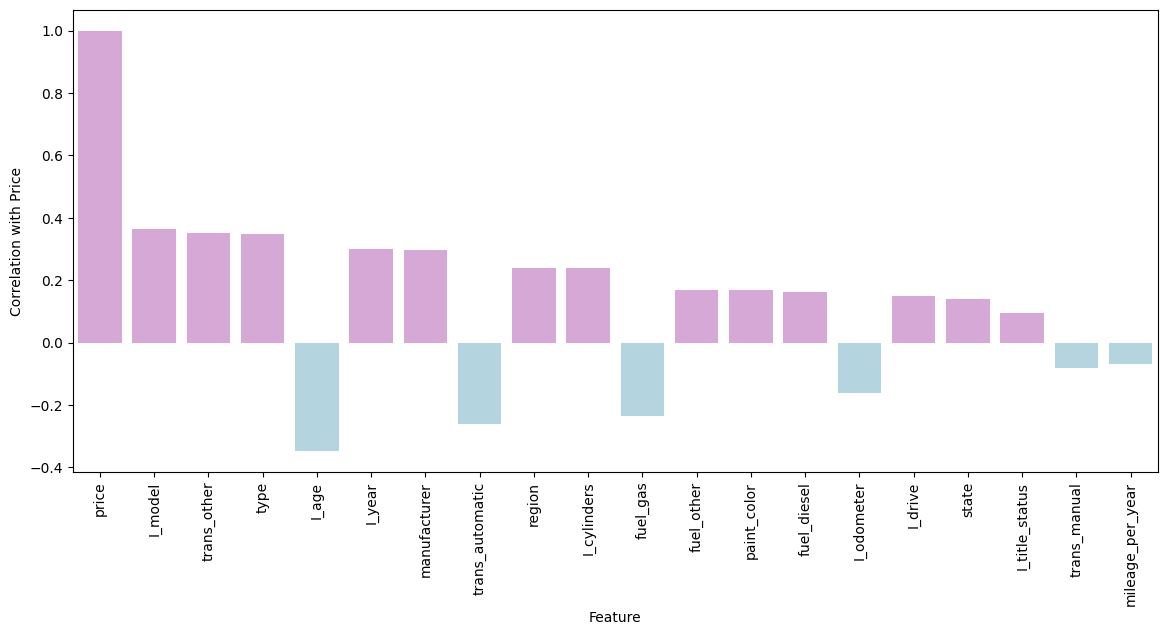

In [37]:
# Get raw correlation (not absolute) for top 20 correlated features
price_corr_signed = corr_matrix['price'].sort_values(key=lambda x: x.abs(), ascending=False).head(20)

# Create DataFrame
price_corr_df_signed = pd.DataFrame({
    'Feature': price_corr_signed.index,
    'Correlation with Price': price_corr_signed.values
}).reset_index(drop=True)

# Assign colors based on sign
colors = ['plum' if val > 0 else 'lightblue' for val in price_corr_df_signed['Correlation with Price']]

# Plot as vertical bar chart
plt.figure(figsize=(14, 6))
plt.xticks(rotation=90)
# Save the plot
plt.savefig("images/top20_corr.png")  # Saves as PNG
sns.barplot(
    data=price_corr_df_signed,
    x='Feature',
    y='Correlation with Price',
    palette=colors,
    
)

In [38]:
'''Not working need to debug so not imputing condiiton droping it a it has lot of NULL values
#Using random forest to imput condition from price price, odometer, age of car, and title_status
known = car_raw[car_raw['condition'].notna()].copy()
missing = car_raw[car_raw['condition'].isna()].copy()

# Encode 'condition' as ordinal
condition_order = ['salvage','fair','good', 'excellent', 'like new', 'new' ]

#Encode condition (leave NaNs as is, use OrdinalEncoder)
condition_encoder = OrdinalEncoder(categories=[condition_order], handle_unknown='use_encoded_value', unknown_value=-1)
car_raw['condition_encoded'] = condition_encoder.fit_transform(car_raw[['condition']])


# Encode condition title_status
title_status_order=['missing','parts only','salvage','rebuilt','lien','clean']
car_raw['title_status_filled'] = car_raw['title_status'].fillna('nodata')

title_encoder = OrdinalEncoder(categories=[title_status_order],handle_unknown='use_encoded_value', unknown_value=-1)
car_raw['title_status_encoded'] = title_encoder.fit_transform(car_raw[['title_status_filled']])

#Split data
known = car_raw[car_raw['condition'].notna()]
missing = car_raw[car_raw['condition'].isna()]

#Train
features = ['price', 'I_odometer', 'I_age' ]#,'title_status_encoded'
target = 'condition_encoded'

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(known[features], known[target])

#Predict Missing Conditions
missing['condition_encoded'] = clf.predict(missing[features])
print(car_raw['title_status_encoded'].unique())
print(known['condition_encoded'].unique())
print(missing['condition_encoded'].unique())

missing['condition'] = condition_encoder.inverse_transform(np.array(missing['condition_encoded']).reshape(-1, 1))

car_raw.loc[car_raw['condition'].isna(), 'condition'] = missing['condition']

'''


"Not working need to debug so not imputing condiiton droping it a it has lot of NULL values\n#Using random forest to imput condition from price price, odometer, age of car, and title_status\nknown = car_raw[car_raw['condition'].notna()].copy()\nmissing = car_raw[car_raw['condition'].isna()].copy()\n\n# Encode 'condition' as ordinal\ncondition_order = ['salvage','fair','good', 'excellent', 'like new', 'new' ]\n\n#Encode condition (leave NaNs as is, use OrdinalEncoder)\ncondition_encoder = OrdinalEncoder(categories=[condition_order], handle_unknown='use_encoded_value', unknown_value=-1)\ncar_raw['condition_encoded'] = condition_encoder.fit_transform(car_raw[['condition']])\n\n\n# Encode condition title_status\ntitle_status_order=['missing','parts only','salvage','rebuilt','lien','clean']\ncar_raw['title_status_filled'] = car_raw['title_status'].fillna('nodata')\n\ntitle_encoder = OrdinalEncoder(categories=[title_status_order],handle_unknown='use_encoded_value', unknown_value=-1)\ncar_raw

In [39]:
'''#  use knn imputer to find condition values based on odometer,  year, before find best value of n by elbow metho

# Prepare data for KNN imputation
# Select relevant columns and handle missing values in those columns
encoder = OrdinalEncoder()
car_raw['I_condition'] = car_raw['condition']

relevant_cols = ['I_age', 'I_odometer','I_condition','price']
car_subset=car_raw[car_raw['I_odometer'].notna()]
car_subset=car_subset[car_subset['I_age'].notna()]
car_subset=car_subset[car_subset['price'].notna()]

car_temp=car_subset
car_subset=car_subset[car_subset['I_condition'].notna()]
car_subset = car_subset[relevant_cols].copy()
car_subset['I_condition'] = encoder.fit_transform(car_subset[['I_condition']])



# Convert categorical features to numerical using one-hot encoding

y=car_subset['I_condition'] 
X=car_subset.drop(columns=['I_condition'])


# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)


# Find the best k value using the Elbow method
mse_values = []
k_values = list(range(1, 21))  # Test k values from 1 to 21

for k in k_values:

  imputer = KNNImputer(n_neighbors=k)
  X_train_imputed = imputer.fit_transform(X_train)
  X_test_imputed = imputer.transform(X_test)


  imputed_values = imputer.fit_transform(X_train)[:, X_train.columns.get_loc('I_age')]
    
  # Access the correct column index for the target variable
  #target_col_index = X_train.columns.get_loc('condition_encoded')  
    
  mse = mean_squared_error(y_train, imputed_values)
  mse_values.append(mse)
    
best_k = k_values[mse_values.index(min(mse_values))]

print(f"Best k value is : {best_k}") '''

'#  use knn imputer to find condition values based on odometer,  year, before find best value of n by elbow metho\n\n# Prepare data for KNN imputation\n# Select relevant columns and handle missing values in those columns\nencoder = OrdinalEncoder()\ncar_raw[\'I_condition\'] = car_raw[\'condition\']\n\nrelevant_cols = [\'I_age\', \'I_odometer\',\'I_condition\',\'price\']\ncar_subset=car_raw[car_raw[\'I_odometer\'].notna()]\ncar_subset=car_subset[car_subset[\'I_age\'].notna()]\ncar_subset=car_subset[car_subset[\'price\'].notna()]\n\ncar_temp=car_subset\ncar_subset=car_subset[car_subset[\'I_condition\'].notna()]\ncar_subset = car_subset[relevant_cols].copy()\ncar_subset[\'I_condition\'] = encoder.fit_transform(car_subset[[\'I_condition\']])\n\n\n\n# Convert categorical features to numerical using one-hot encoding\n\ny=car_subset[\'I_condition\'] \nX=car_subset.drop(columns=[\'I_condition\'])\n\n\n# Split the data into training and testing sets\nX_train, X_test, y_train, y_test = train_tes

In [40]:
'''# based on k=1 impute na values for I_condition
imputer = KNNImputer(n_neighbors=1)

# Select relevant columns for imputation (including 'I_condition')
relevant_cols = ['I_age', 'I_odometer', 'price']

imputer.fit(car_subset[['I_age', 'I_odometer', 'price']])

# Perform KNN imputation on the selected columns
imputed_data = imputer.transform(car_temp[car_temp['I_condition'].isna()][['I_age', 'I_odometer', 'price']])
predicted_condition = imputed_data[:, X_test.columns.get_loc('I_condition')]

# Inverse transform 'I_condition' back to original categories
#car_subset_imputed['I_condition'] = encoder.inverse_transform(car_subset_imputed[['I_condition']])

# Update the original DataFrame 'car_raw' with the imputed values
#car_raw['O_condition'] = car_subset_imputed['I_condition']

print(predicted_condition)'''


"# based on k=1 impute na values for I_condition\nimputer = KNNImputer(n_neighbors=1)\n\n# Select relevant columns for imputation (including 'I_condition')\nrelevant_cols = ['I_age', 'I_odometer', 'price']\n\nimputer.fit(car_subset[['I_age', 'I_odometer', 'price']])\n\n# Perform KNN imputation on the selected columns\nimputed_data = imputer.transform(car_temp[car_temp['I_condition'].isna()][['I_age', 'I_odometer', 'price']])\npredicted_condition = imputed_data[:, X_test.columns.get_loc('I_condition')]\n\n# Inverse transform 'I_condition' back to original categories\n#car_subset_imputed['I_condition'] = encoder.inverse_transform(car_subset_imputed[['I_condition']])\n\n# Update the original DataFrame 'car_raw' with the imputed values\n#car_raw['O_condition'] = car_subset_imputed['I_condition']\n\nprint(predicted_condition)"

In [41]:
# Handle   errors if 'I_age' is not numeric.
car_raw_encoded['I_age'] = pd.to_numeric(car_raw_encoded['I_age'], errors='coerce')

# Calculate L_age as log(I_age) 
car_raw_encoded['L_age'] = np.log(car_raw_encoded['I_age'])

# Replace infinite values resulting from log(0) or log(negative) with NaN.
car_raw_encoded['L_age'] = car_raw_encoded['L_age'].replace([np.inf, -np.inf], np.nan)


---
## 🧠 3. Modeling

In this section, we develop and evaluate machine learning models to predict the price of used cars based on various features. We use techniques such as polynomial regression, pipeline workflows, feature scaling, and cross-validation to build robust and interpretable models.

---

In [42]:
#car_raw_encoded=pd.read_csv('data/car_raw_encoded.csv')
car_raw_encoded.info()
columns = ['Model', 'Degree', 'MSE', 'R² Train', 'R² Test','param']
car_raw_encoded.to_csv('data/car_raw_encoded.csv',index=False) ###Take backup

<class 'pandas.core.frame.DataFrame'>
Index: 405334 entries, 27 to 426879
Data columns (total 27 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   region            405334 non-null  float64
 1   manufacturer      405334 non-null  float64
 2   type              405334 non-null  float64
 3   paint_color       405334 non-null  float64
 4   state             405334 non-null  float64
 5   I_model           405334 non-null  float64
 6   I_year            405334 non-null  float64
 7   I_age             405334 non-null  float64
 8   I_cylinders       405334 non-null  float64
 9   I_odometer        405334 non-null  float64
 10  I_condition       405334 non-null  float64
 11  I_title_status    405334 non-null  float64
 12  I_drive           405334 non-null  float64
 13  trans_automatic   405334 non-null  int64  
 14  trans_manual      405334 non-null  int64  
 15  trans_other       405334 non-null  int64  
 16  trans_nan         405334

---
#### 3.1 Simple Linear  Regression Model
---

In [43]:
final_results=[]
# Define features and target
features = [
    'region', 'manufacturer', 'type', 'paint_color', 'state',
    'I_model', 'I_year', 'I_age', 'I_cylinders', 'I_odometer',
    'I_title_status', 'trans_automatic', 'trans_manual',
    'trans_other', 'trans_nan', 'I_drive',  
    'fuel_diesel', 'fuel_electric',
    'fuel_gas', 'fuel_hybrid', 'fuel_other', 'fuel_nan','I_condition','mileage_per_year','price_per_mile','L_age'
]

X = car_raw_encoded[features]
y = car_raw_encoded['price']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and fit the model
poly_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('poly_features', PolynomialFeatures(degree=1, include_bias=False)),
        ('regressor', LinearRegression())
    ])

# Predict
poly_pipeline.fit(X_train, y_train)
y_pred = poly_pipeline.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
final_results.append(('Simple_linear_Regression',0,mse))

print(f"MSE: {mse:.2f}")


MSE: 70818016.39


In [44]:
####Save the model
model_filename = 'data/Simple_linear_Regression.joblib'
# Save the model
joblib.dump(poly_pipeline, model_filename)

['data/Simple_linear_Regression.joblib']

---
### 📈 1. Predicted vs Actual Prices (Scatter Plot)

This plot compares the actual car prices from the test dataset with the prices predicted by our linear regression model. Ideally, the points should align along the 45-degree red reference line, indicating perfect predictions. The spread of the points around this line helps us visually assess the accuracy and performance of our model.

A tight clustering along the line suggests good model performance, while a wide spread indicates potential areas for model improvement .

---

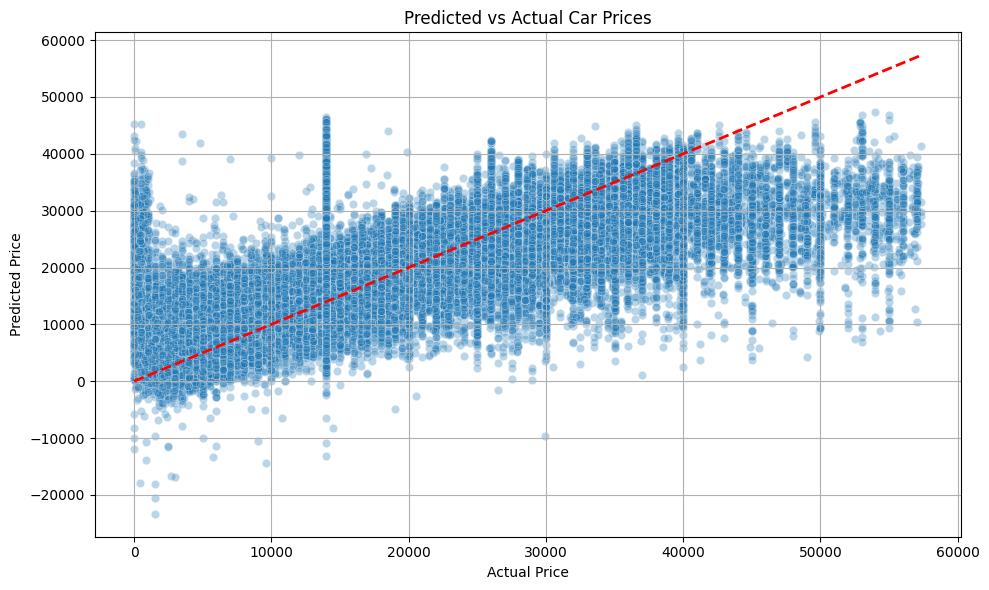

In [45]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Predicted vs Actual Car Prices')
plt.grid(True)
plt.tight_layout()
plt.show()

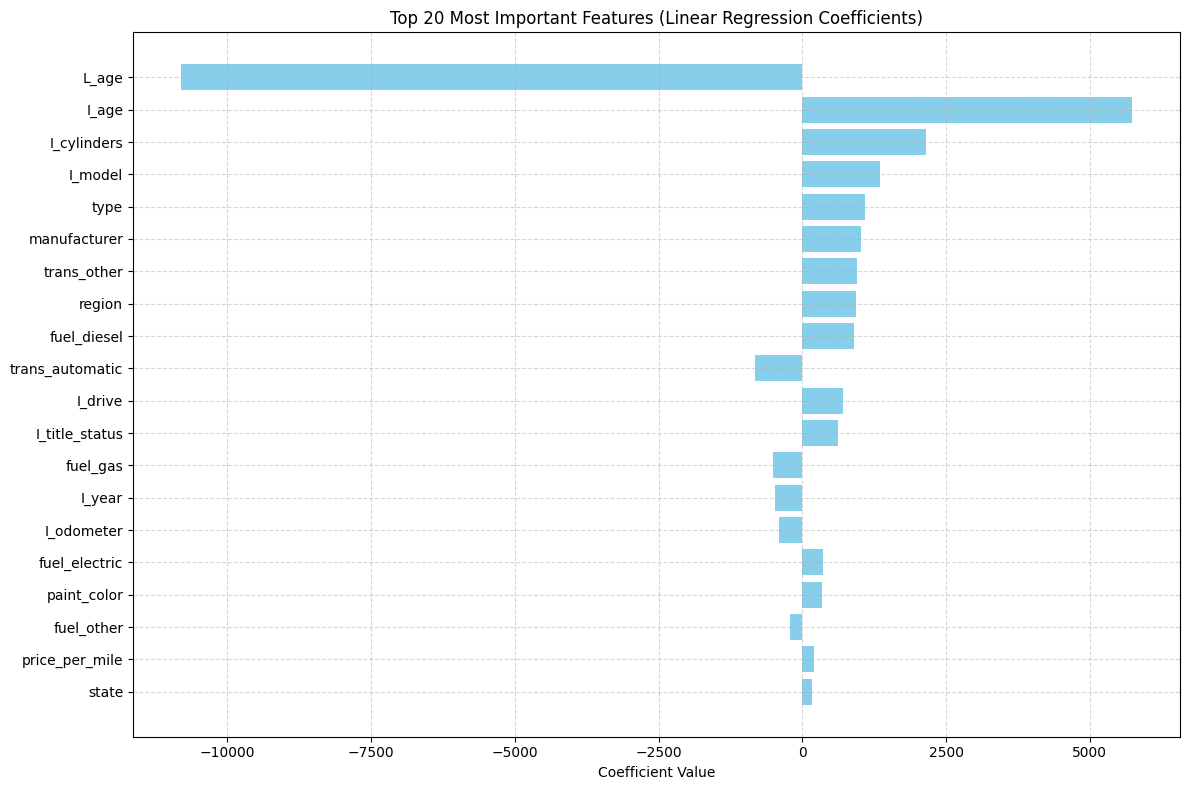

In [46]:
# === 2. Feature Importance Plot ===
# Step 1: Get the feature names after polynomial transformation
feature_names = poly_pipeline.named_steps['poly_features'].get_feature_names_out(X.columns)

# Step 2: Get the coefficients from the fitted linear regression model
coefficients = poly_pipeline.named_steps['regressor'].coef_

# Step 3: Create a DataFrame for plotting
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Step 4: Sort features by absolute value of coefficients for better visibility
coef_df['abs_coeff'] = coef_df['Coefficient'].abs()
coef_df_sorted = coef_df.sort_values(by='abs_coeff', ascending=False).head(20)  # Top 20 features

# Step 5: Plot
plt.figure(figsize=(12, 8))
plt.barh(coef_df_sorted['Feature'], coef_df_sorted['Coefficient'], color='skyblue')
plt.xlabel('Coefficient Value')
plt.title('Top 20 Most Important Features (Linear Regression Coefficients)')
plt.gca().invert_yaxis()  # Largest on top
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
# Save the plot
plt.savefig("images/top20_lr.png")  # Saves as PNG
plt.show()

---
## 🧠 3. Modeling

In this section, we develop and evaluate machine learning models to predict the price of used cars based on various features. We use techniques such as polynomial regression, pipeline workflows, feature scaling, and cross-validation to build robust and interpretable models.

---


In [47]:
best_degree = None
best_mse = float('inf')
results = []


for degree in range(1, 4):
    poly_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('poly_features', PolynomialFeatures(degree=degree, include_bias=False)),
        ('regressor', LinearRegression())
    ])
    
    poly_pipeline.fit(X_train, y_train)
    y_pred = poly_pipeline.predict(X_test)
    y_train_pred = poly_pipeline.predict(X_train)
    
    mse = mean_squared_error(y_test, y_pred)
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_pred)
    
    results.append((degree, mse))
    final_results.append(('Polynomial_features', degree, mse, r2_train, r2_test))
    
    print(f"Degree {degree}, MSE: {mse:.0f}, R² Train: {r2_train:.4f}, R² Test: {r2_test:.4f}")
     
    if mse < best_mse:
        best_mse = mse
        best_degree = degree

print(f"\n✅ Best Polynomial Degree: {best_degree}")

Degree 1, MSE: 70818016, R² Train: 0.5214, R² Test: 0.5234
Degree 2, MSE: 466521, R² Train: 0.9967, R² Test: 0.9969
Degree 3, MSE: 132696, R² Train: 0.9996, R² Test: 0.9991

✅ Best Polynomial Degree: 3


In [48]:
####Save the model
model_filename = 'data/Polynomial_features.joblib'
# Save the model
joblib.dump(poly_pipeline, model_filename)

['data/Polynomial_features.joblib']

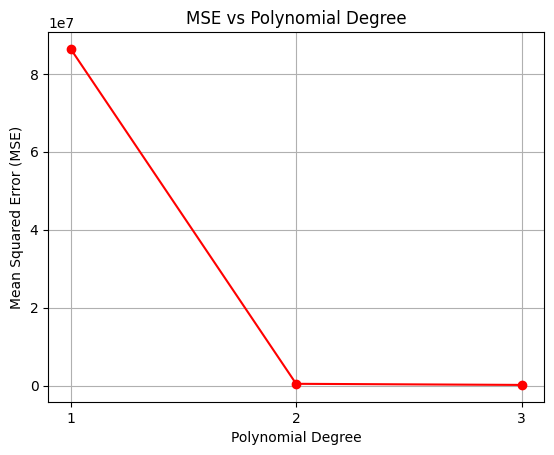

In [49]:
''' Saving results

Degree 1, MSE: 85799610
Degree 2, MSE: 65601124
Degree 3, MSE: 84413847
Degree 4, MSE: 177773260

'''

# Extract degrees and MSE values
degrees = [1,2,3]
mse_values = [86384548,474008,188684]

# Plot MSE vs Polynomial Degree
plt.plot(degrees, mse_values, marker='o', color='red')
plt.title('MSE vs Polynomial Degree')
plt.xlabel('Polynomial Degree')
plt.ylabel('Mean Squared Error (MSE)')
plt.grid(True)
plt.xticks(degrees)
# Save the plot
plt.savefig("images/mse_ploy_degree.png")  # Saves as PNG
plt.show()

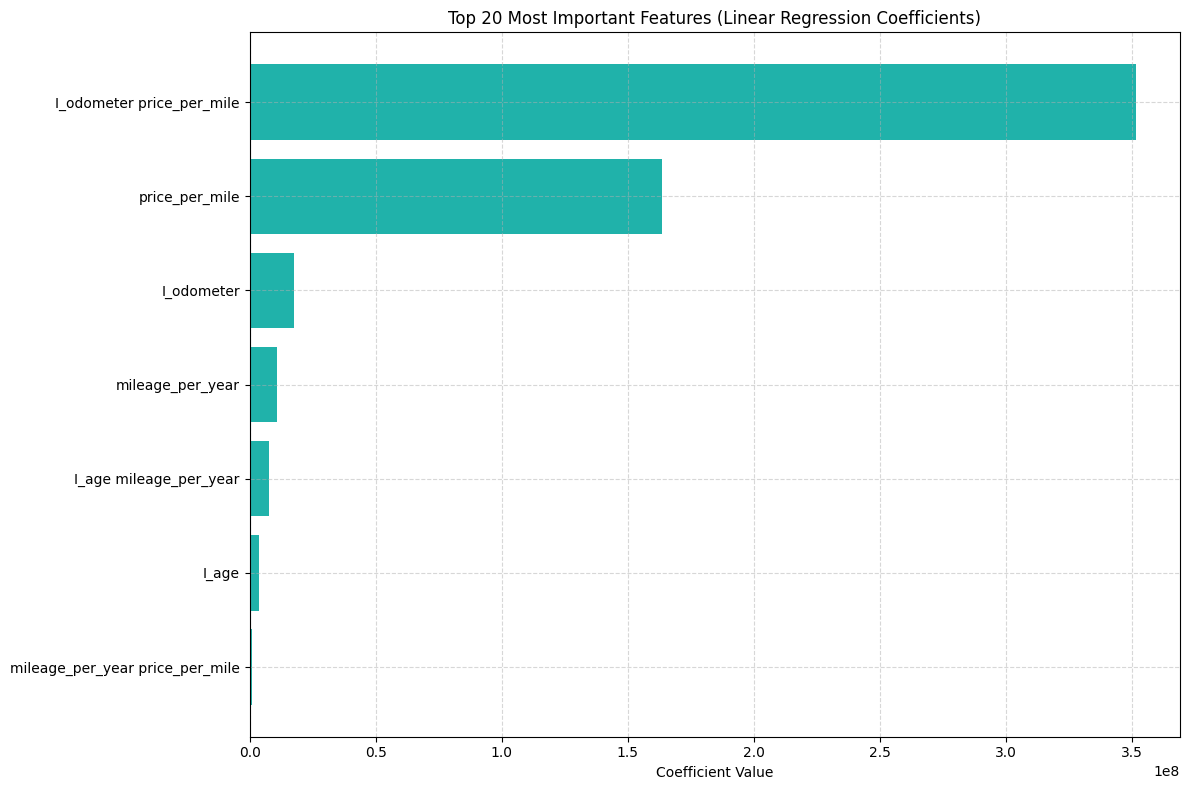

In [50]:
# === 2. Feature Importance Plot for degree 2 ===
poly_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('poly_features', PolynomialFeatures(degree=2, include_bias=False)),
        ('regressor', LinearRegression())
    ])

poly_pipeline.fit(X_train, y_train)
y_pred = poly_pipeline.predict(X_test)
y_train_pred = poly_pipeline.predict(X_train)
    
mse = mean_squared_error(y_test, y_pred)
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_pred)

# Step 1: Get the feature names after polynomial transformation
feature_names = poly_pipeline.named_steps['poly_features'].get_feature_names_out(X.columns)

# Step 2: Get the coefficients from the fitted linear regression model
coefficients = poly_pipeline.named_steps['regressor'].coef_

# Step 3: Create a DataFrame for plotting
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Step 4: Sort features by absolute value of coefficients for better visibility
coef_df['abs_coeff'] = coef_df['Coefficient'].abs()
coef_df_sorted = coef_df.sort_values(by='abs_coeff', ascending=False).head(7)  # Top 20 features

# Step 5: Plot
plt.figure(figsize=(12, 8))
plt.barh(coef_df_sorted['Feature'], coef_df_sorted['Coefficient'], color='lightseagreen')
plt.xlabel('Coefficient Value')
plt.title('Top 20 Most Important Features (Linear Regression Coefficients)')
plt.gca().invert_yaxis()  # Largest on top
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
# Save the plot
plt.savefig("images/top20_bar_lr.png")  # Saves as PNG
plt.show()

---
<span style="color:red; font-weight:bold;">Above model is overfitted as seen odometer*price per mile gives price, So removing price per mile</span>

---


In [51]:
final_results=[]
# Define features and target
features = [
    'region', 'manufacturer', 'type', 'paint_color', 'state',
    'I_model', 'I_year', 'I_age', 'I_cylinders', 'I_odometer',
    'I_title_status', 'trans_automatic', 'trans_manual','trans_other', 
    'trans_nan', 'I_drive', 'fuel_diesel', 'fuel_electric','fuel_gas', 
    'fuel_hybrid', 'fuel_other', 'fuel_nan','I_condition','mileage_per_year' ,'L_age'
]

X = car_raw_encoded[features]
y = car_raw_encoded['price']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and fit the model
poly_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('poly_features', PolynomialFeatures(degree=1, include_bias=False)),
        ('regressor', LinearRegression())
    ])

# Predict
poly_pipeline.fit(X_train, y_train)
y_pred = poly_pipeline.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
final_results.append(('Simple_linear_Regression',0,mse))

print(f"MSE: {mse:.2f}")


MSE: 70845549.96


In [52]:
####Save the model
model_filename = 'data/Simple_linear_Regression_corrected.joblib'
# Save the model
joblib.dump(poly_pipeline, model_filename)

['data/Simple_linear_Regression_corrected.joblib']

In [53]:
best_degree = None
best_mse = float('inf')
results = []


for degree in range(1, 4):
    poly_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('poly_features', PolynomialFeatures(degree=degree, include_bias=False)),
        ('regressor', LinearRegression())
    ])
    
    poly_pipeline.fit(X_train, y_train)
    y_pred = poly_pipeline.predict(X_test)
    y_train_pred = poly_pipeline.predict(X_train)
    
    mse = mean_squared_error(y_test, y_pred)
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_pred)
    
    results.append((degree, mse))
    final_results.append(('Polynomial_features_corrected', degree, mse, r2_train, r2_test))
    
    print(f"Degree {degree}, MSE: {mse:.0f}, R² Train: {r2_train:.4f}, R² Test: {r2_test:.4f}")
     
    if mse < best_mse:
        best_mse = mse
        best_degree = degree

print(f"\n✅ Best Polynomial Degree: {best_degree}")

Degree 1, MSE: 70845550, R² Train: 0.5211, R² Test: 0.5232
Degree 2, MSE: 61770388, R² Train: 0.5919, R² Test: 0.5843
Degree 3, MSE: 461779981, R² Train: 0.6487, R² Test: -2.1078

✅ Best Polynomial Degree: 2


In [54]:
####Save the model
model_filename = 'data/Polynomial_features_corrected.joblib'
# Save the model
joblib.dump(poly_pipeline, model_filename)

['data/Polynomial_features_corrected.joblib']

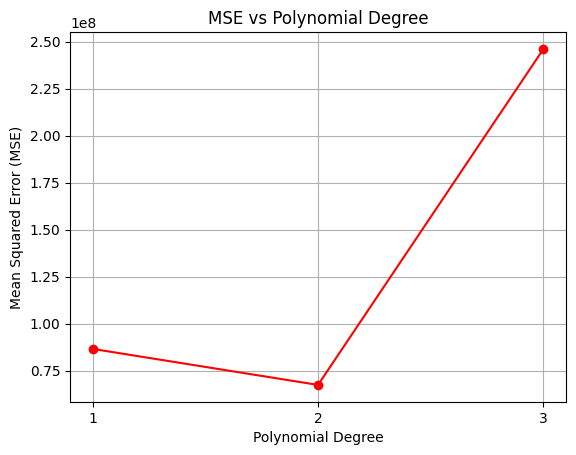

In [55]:
''' Saving results

Degree 1, MSE: 86549163
Degree 2, MSE: 67385764
Degree 3, MSE: 246094440

'''

# Extract degrees and MSE values
degrees = [1,2,3]
mse_values = [86549163,67385764,246094440]

# Plot MSE vs Polynomial Degree
plt.plot(degrees, mse_values, marker='o', color='red')
plt.title('MSE vs Polynomial Degree')
plt.xlabel('Polynomial Degree')
plt.ylabel('Mean Squared Error (MSE)')
plt.grid(True)
plt.xticks(degrees)
# Save the plot
plt.savefig("images/mse_vs_poly_lr.png")  # Saves as PNG
plt.show()

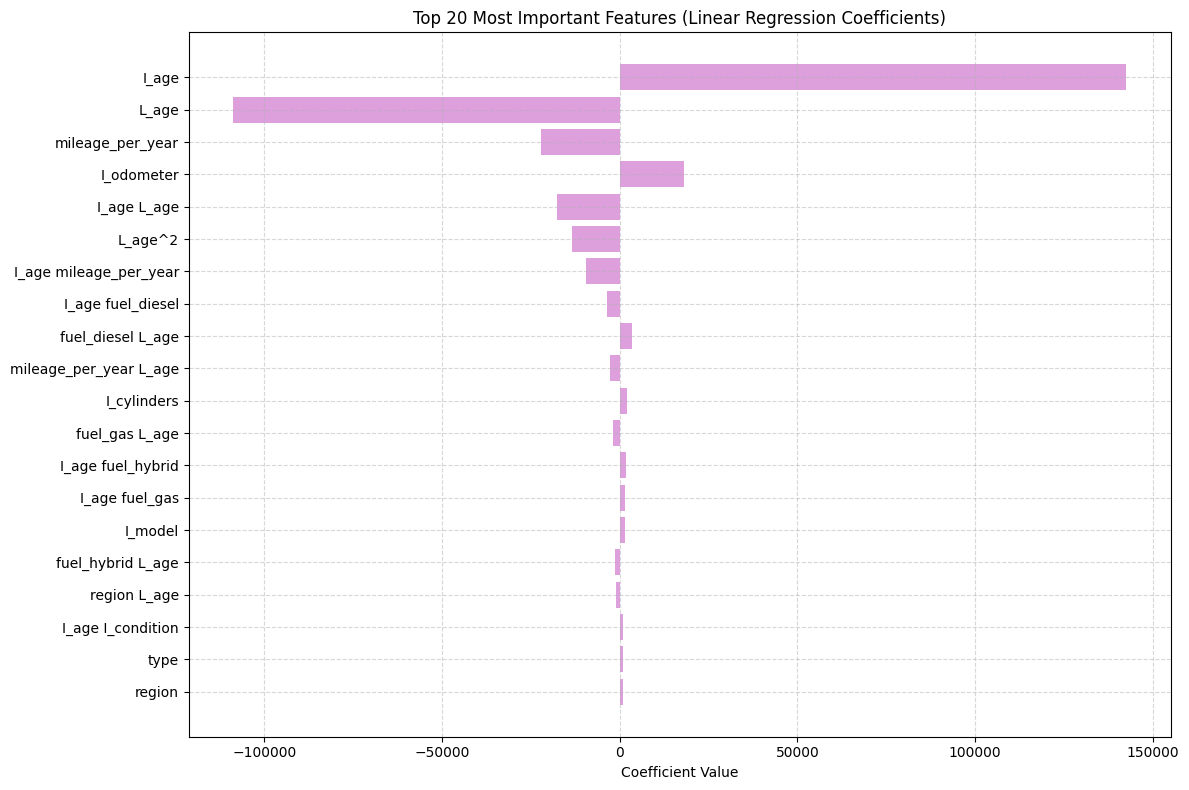

In [56]:
# === 2. Feature Importance Plot for degree 2 ===
poly_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('poly_features', PolynomialFeatures(degree=2, include_bias=False)),
        ('regressor', LinearRegression())
    ])

poly_pipeline.fit(X_train, y_train)
y_pred = poly_pipeline.predict(X_test)
y_train_pred = poly_pipeline.predict(X_train)
    
mse = mean_squared_error(y_test, y_pred)
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_pred)

# Step 1: Get the feature names after polynomial transformation
feature_names = poly_pipeline.named_steps['poly_features'].get_feature_names_out(X.columns)

# Step 2: Get the coefficients from the fitted linear regression model
coefficients = poly_pipeline.named_steps['regressor'].coef_

# Step 3: Create a DataFrame for plotting
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Step 4: Sort features by absolute value of coefficients for better visibility
coef_df['abs_coeff'] = coef_df['Coefficient'].abs()
coef_df_sorted = coef_df.sort_values(by='abs_coeff', ascending=False).head(20)  # Top 20 features

# Step 5: Plot
plt.figure(figsize=(12, 8))
plt.barh(coef_df_sorted['Feature'], coef_df_sorted['Coefficient'], color='plum')
plt.xlabel('Coefficient Value')
plt.title('Top 20 Most Important Features (Linear Regression Coefficients)')
plt.gca().invert_yaxis()  # Largest on top
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
# Save the plot
plt.savefig("images/top20_poly_lr.png")  # Saves as PNG
plt.show()

---
#### 3.1 K-Fold cross-validation

---

In [57]:
# K-Fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
mse_scores = []

kfold_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('poly_features', PolynomialFeatures(degree=2, include_bias=False)),
        ('regressor', LinearRegression())
    ])

for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    kfold_pipeline.fit(X_train, y_train)
    y_pred = kfold_pipeline.predict(X_test)
    y_train_pred=kfold_pipeline.predict(X_train)
    mse = mean_squared_error(y_test, y_pred)
    
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_pred)
    mse_scores.append((mse,r2_train,r2_test))
    final_results.append(('Polynomial_features_corrected_Kfold', degree, mse, r2_train, r2_test ))
    
    # Print MSE for each fold and average MSE
    print(f"Fold {len(mse_scores)}: MSE = {mse:.2f}, R² Train: {r2_train:.4f}, R² Test: {r2_test:.4f}")

relevant_results = [result for result in final_results if result[0] == 'Polynomial_features_corrected_Kfold']


# Calculate averages for MSE and R² for these results
average_mse = np.mean([result[2] for result in relevant_results])
average_r2_train = np.mean([result[3] for result in relevant_results])
average_r2_test = np.mean([result[4] for result in relevant_results])

print(f"\nAverage MSE: {average_mse:.2f}")
print(f"Average R² Train: {average_r2_train:.4f}")
print(f"Average R² Test: {average_r2_test:.4f}")

Fold 1: MSE = 61770388.00, R² Train: 0.5919, R² Test: 0.5843
Fold 2: MSE = 61291422.26, R² Train: 0.5921, R² Test: 0.5874
Fold 3: MSE = 62186261.99, R² Train: 0.5928, R² Test: 0.5850
Fold 4: MSE = 60832585.59, R² Train: 0.5913, R² Test: 0.5923
Fold 5: MSE = 61128453.68, R² Train: 0.5922, R² Test: 0.5895

Average MSE: 61441822.30
Average R² Train: 0.5921
Average R² Test: 0.5877


---
## 📐 Polynomial Regression: Degree Selection & Feature Reduction Strategy

Using the **elbow method** on Mean Squared Error (MSE) across polynomial degrees, we observe that:

- MSE drops significantly until **degree 2**, after which the gain is minimal.
- Therefore, **degree 2** is optimal for balancing complexity and performance.

Before proceeding to feature reduction, we will perform **cross-validation** to validate our findings and ensure generalization across different data splits.

---


### 🔧 3.2 Feature Reduction Strategy

To manage the **computational complexity** introduced by polynomial features, we will apply **dimensionality reduction** techniques:

1. **Principal Component Analysis (PCA)**  
   - Projects data into orthogonal components while retaining maximum variance.
   - Ideal for reducing multicollinearity and dimensionality in transformed feature space.

2. **Feature Selection Based on Importance**  
   - Using model-based approaches (e.g., feature importances from Random Forest or Lasso).
   - Helps retain only the most influential predictors.


> ✅ We will start with PCA for fast dimensionality compression  
> 🔍 Then apply model-based or statistical techniques for refinement

---

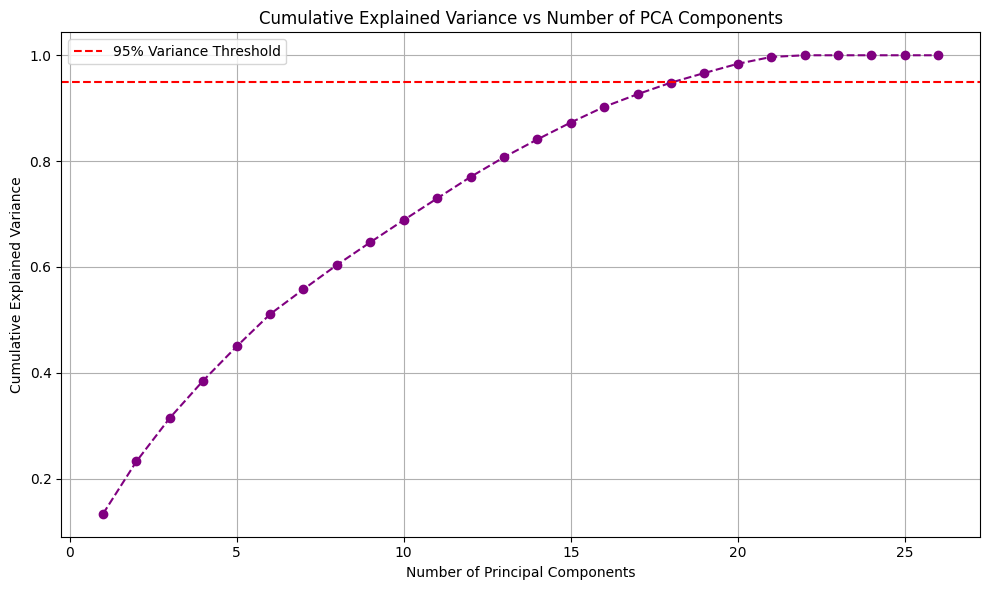

In [58]:
# Drop target variable 'price' before PCA
X = car_raw_encoded.drop(columns=['price'])

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Plot cumulative explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, X.shape[1] + 1), pca.explained_variance_ratio_.cumsum(), 
         marker='o', linestyle='--', color='purple')
plt.axhline(y=0.95, color='red', linestyle='--', label='95% Variance Threshold')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance vs Number of PCA Components')
plt.grid(True)
plt.legend()
plt.tight_layout()
# Save the plot
plt.savefig("images/pca1.png")  # Saves as PNG
plt.show()

---
#### 📊 Scree Plot: Explained Variance by Each PCA Component
---

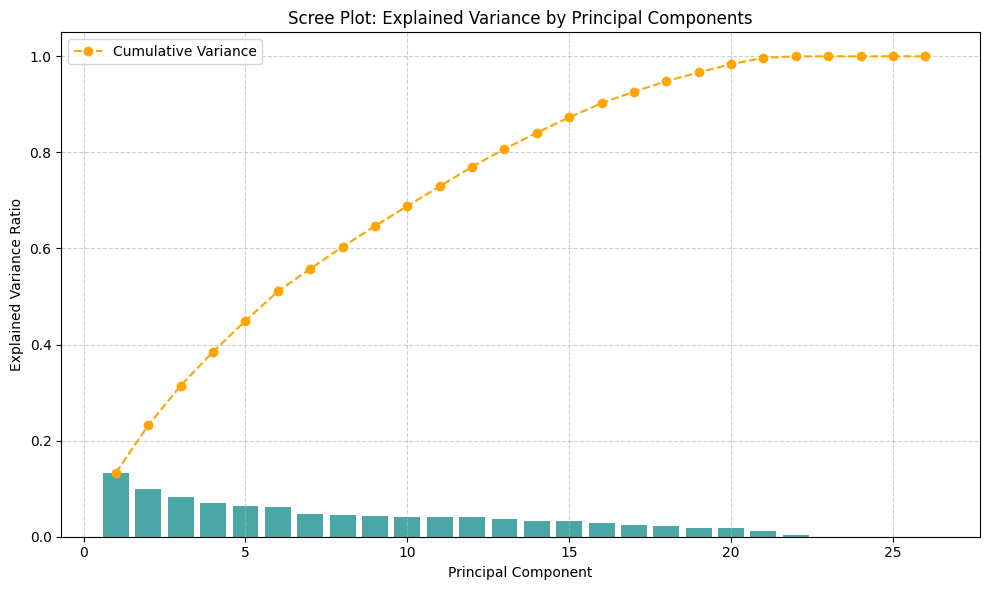

In [59]:
# SCreetPlot the explained variance for each component
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_,
        alpha=0.7, color='teal')
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
         np.cumsum(pca.explained_variance_ratio_), 
         marker='o', color='orange', linestyle='--', label='Cumulative Variance')

plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot: Explained Variance by Principal Components')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
# Save the plot
plt.savefig("images/scree.png")  # Saves as PNG
plt.show()

In [60]:
# Choose number of components (based on scree plot or cumulative explained variance)
n_components = 20  # Example: keep enough to explain ~95% variance
best_degree = None
best_mse = float('inf')
results = []

for degree in range(1,3):
# Pipeline with PCA and Regression
    pca_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=n_components)),
        ('poly_features', PolynomialFeatures(degree=degree, include_bias=False)),
        ('regressor', LinearRegression())
    ])

 

    # Fit and predict
    pca_pipeline.fit(X_train, y_train)
    y_pred_pca = pca_pipeline.predict(X_test)
    y_train_pred = pca_pipeline.predict(X_train)

    # Evaluate
    mse_pca = mean_squared_error(y_test, y_pred_pca)
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_pred_pca)
    results.append((degree, mse_pca))

     
    
    
    mse = mean_squared_error(y_test, y_pred)
    
    
    results.append((degree, mse))
    final_results.append(('PCA_Polynomial_features', degree, mse_pca, r2_train, r2_test))
    
    print(f"Degree {degree}, MSE: {mse_pca:.0f}, R² Train: {r2_train:.4f}, R² Test: {r2_test:.4f}")
     

    if mse < best_mse:
        best_mse = mse_pca
        best_degree = degree
    
print(f"📉 MSE After PCA (n={n_components}): {mse_pca:.2f}")
print(f"\n✅ Best Polynomial Degree: {best_degree}")

Degree 1, MSE: 82177822, R² Train: 0.4500, R² Test: 0.4481
Degree 2, MSE: 63138242, R² Train: 0.5796, R² Test: 0.5760
📉 MSE After PCA (n=20): 63138242.06

✅ Best Polynomial Degree: 2


In [61]:
####Save the model
model_filename = 'data/PCA_Polynomial_features.joblib'
# Save the model
joblib.dump(pca_pipeline, model_filename)

['data/PCA_Polynomial_features.joblib']

In [62]:
###Take result backup
#df_final_results = pd.DataFrame(final_results, columns=columns)
#df_final_results.to_csv('data/df_final_results.csv',index=False)
#print(df_final_results)

---
#### 3.3 Using XGboost Regressor
---

✅ MSE: 33108522, R² Train: 0.8245, R² Test: 0.7772


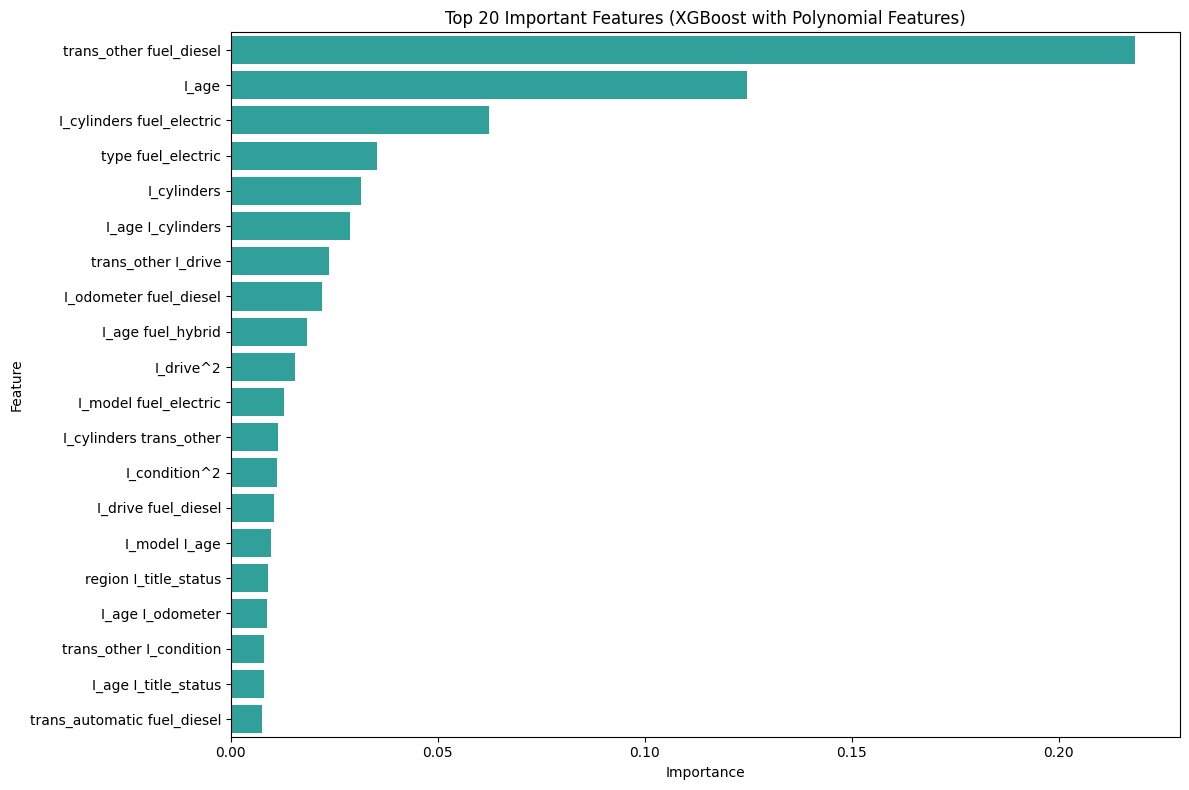

In [63]:
# Define features and target
features = [
    'region', 'manufacturer', 'type', 'paint_color', 'state',
    'I_model', 'I_year', 'I_age', 'I_cylinders', 'I_odometer',
    'I_title_status', 'trans_automatic', 'trans_manual','trans_other', 
    'trans_nan', 'I_drive', 'fuel_diesel', 'fuel_electric','fuel_gas', 
    'fuel_hybrid', 'fuel_other', 'fuel_nan','I_condition','mileage_per_year' 
]

X = car_raw_encoded[features]
y = car_raw_encoded['price']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgboost_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly_features', PolynomialFeatures(degree=2, include_bias=False)),
    ('regressor', XGBRegressor(n_estimators=200, random_state=42, verbosity=0))
])

# Fit and predict
xgboost_pipeline.fit(X_train, y_train)
y_pred = xgboost_pipeline.predict(X_test)
y_train_pred = xgboost_pipeline.predict(X_train)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_pred)

print(f"✅ MSE: {mse:.0f}, R² Train: {r2_train:.4f}, R² Test: {r2_test:.4f}")

final_results.append(('XGboost_Polynomial_features', degree, mse, r2_train, r2_test))
# 🔍 Feature Importance
# Step 1: Get feature names after polynomial transformation
feature_names = xgboost_pipeline.named_steps['poly_features'].get_feature_names_out(X.columns)

# Step 2: Get feature importances from XGBoost
importances = xgboost_pipeline.named_steps['regressor'].feature_importances_

# Step 3: Create a DataFrame for plotting
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Optional: plot

plt.figure(figsize=(12, 8))
sns.barplot(data=coef_df.head(20), x='Importance', y='Feature',color='lightseagreen')
plt.title('Top 20 Important Features (XGBoost with Polynomial Features)')
plt.tight_layout()
plt.show()

In [64]:
####Save the model
model_filename = 'data/XGboost_Polynomial_features.joblib'
# Save the model
joblib.dump(xgboost_pipeline, model_filename)

['data/XGboost_Polynomial_features.joblib']

---
#### 3.3.1 GirdSearchCV for hyperparmeter tuning 

---

In [65]:
xgboost_pipeline = Pipeline([
    #('scaler', StandardScaler()),
    ('poly_features', PolynomialFeatures(degree=2, include_bias=False)),
    ('regressor', XGBRegressor(random_state=42, verbosity=0))
])

# Parameter grid for XGBoost
param_grid = {
    'regressor__n_estimators': [200,300],
    'regressor__max_depth': [6,7],
    'regressor__learning_rate': [0.2,0.3],
    'regressor__subsample': [0.6,0.7]
}

# GridSearchCV setup
grid_search = GridSearchCV(
    estimator=xgboost_pipeline,
    param_grid=param_grid,
    scoring='r2',
    cv=3,
    verbose=1,
    n_jobs=-1
)

# Fit GridSearchCV
grid_search.fit(X_train, y_train)

# Print results for each parameter tested
for i in range(len(grid_search.cv_results_['params'])):
    params = grid_search.cv_results_['params'][i]
    
    # Get the mean score for this set of parameters (using R²)
    mean_test_score = grid_search.cv_results_['mean_test_score'][i]
    
    # Now, we'll use the corresponding model to calculate the training score manually
    xgb_params = {k.replace('regressor__', ''): v for k, v in params.items()}
    model = XGBRegressor(**xgb_params, random_state=42, verbosity=0)
    
    
    # Rebuild pipeline with the current parameter settings
    temp_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('poly_features', PolynomialFeatures(degree=2, include_bias=False)),
        ('regressor', model)
    ])
    
    # Fit the model and calculate training R² manually
    temp_pipeline.fit(X_train, y_train)
    y_train_pred = temp_pipeline.predict(X_train)
    r2_train = r2_score(y_train, y_train_pred)
    
    # Now, evaluate on test set
    y_pred = temp_pipeline.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2_test = r2_score(y_test, y_pred)
    
    final_results.append(('GridSearchCV_XGboost', degree, mse, r2_train, r2_test,params))

    # Print results
    print(f"Params: {params}")
    print(f"✅ Mean Test R²: {mean_test_score:.4f}, Mean Train R²: {r2_train:.4f}")
    print(f"✅ MSE: {mse:.0f}, R² Train: {r2_train:.4f}, R² Test: {r2_test:.4f}")
    print("-" * 60)

# Print the best parameters after GridSearch
print(f"✅ Best Params: {grid_search.best_params_}")


Fitting 3 folds for each of 16 candidates, totalling 48 fits


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Params: {'regressor__learning_rate': 0.2, 'regressor__max_depth': 6, 'regressor__n_estimators': 200, 'regressor__subsample': 0.6}
✅ Mean Test R²: 0.7505, Mean Train R²: 0.7994
✅ MSE: 35436428, R² Train: 0.7994, R² Test: 0.7615
------------------------------------------------------------
Params: {'regressor__learning_rate': 0.2, 'regressor__max_depth': 6, 'regressor__n_estimators': 200, 'regressor__subsample': 0.7}
✅ Mean Test R²: 0.7543, Mean Train R²: 0.8011
✅ MSE: 34903556, R² Train: 0.8011, R² Test: 0.7651
------------------------------------------------------------
Params: {'regressor__learning_rate': 0.2, 'regressor__max_depth': 6, 'regressor__n_estimators': 300, 'regressor__subsample': 0.6}
✅ Mean Test R²: 0.7631, Mean Train R²: 0.8261
✅ MSE: 33181224, R² Train: 0.8261, R² Test: 0.7767
------------------------------------------------------------
Params: {'regressor__learning_rate': 0.2, 'regressor__max_depth': 6, 'regressor__n_estimators': 300, 'regressor__subsample': 0.7}
✅ Mean

In [66]:
####Save the model
best_model = grid_search.best_estimator_
# Save the best model to disk
joblib.dump(best_model, "data/GridSearchCV_XGboost.joblib")

['data/GridSearchCV_XGboost.joblib']

### ---
#### Run XGBoot with best Hyper parameters 
#### Best Params: {'regressor__learning_rate': 0.2, 'regressor__max_depth': 7, 'regressor__n_estimators': 300, 'regressor__subsample': 0.7}
---

✅ MSE: 31101050, R² Train: 0.8520, R² Test: 0.7907


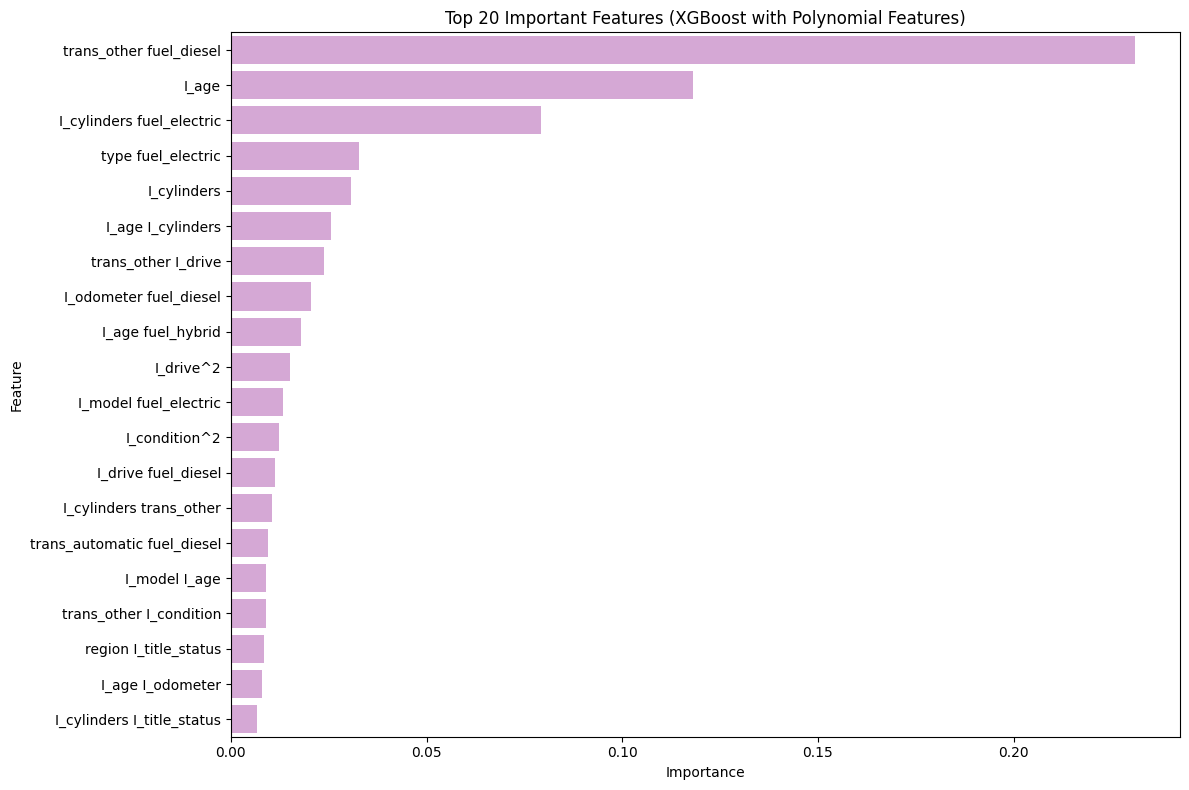

In [67]:
xgboost_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly_features', PolynomialFeatures(degree=2, include_bias=False)),
    ('regressor', XGBRegressor(n_estimators=300,regressor__max_depth=7,regressor__learning_rate=0.2 ,regressor__subsample=0.7,random_state=42, verbosity=0))
])

# Fit and predict
xgboost_pipeline.fit(X_train, y_train)
y_pred = xgboost_pipeline.predict(X_test)
y_train_pred = xgboost_pipeline.predict(X_train)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_pred)

print(f"✅ MSE: {mse:.0f}, R² Train: {r2_train:.4f}, R² Test: {r2_test:.4f}")

final_results.append(('XGboost_Polynomial_features_best', degree, mse, r2_train, r2_test,'n_estimators=200,regressor__max_depth=7,regressor__learning_rate=0.2'))
# 🔍 Feature Importance
# Step 1: Get feature names after polynomial transformation
feature_names = xgboost_pipeline.named_steps['poly_features'].get_feature_names_out(X.columns)

# Step 2: Get feature importances from XGBoost
importances = xgboost_pipeline.named_steps['regressor'].feature_importances_

# Step 3: Create a DataFrame for plotting
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Optional: plot

plt.figure(figsize=(12, 8))
sns.barplot(data=coef_df.head(20), x='Importance', y='Feature',color='plum')
plt.title('Top 20 Important Features (XGBoost with Polynomial Features)')
plt.tight_layout()
# Save the plot
plt.savefig("images/top20_xg.png")  # Saves as PNG
plt.show()

In [68]:
####Save the model
model_filename = 'data/XGboost_Polynomial_features_best.joblib'
# Save the model
joblib.dump(xgboost_pipeline, model_filename)

['data/XGboost_Polynomial_features_best.joblib']

---
#### 3.4 Using Ridge Regressor
---

✅ MSE: 67385676, R² Train: 0.5563, R² Test: 0.5465


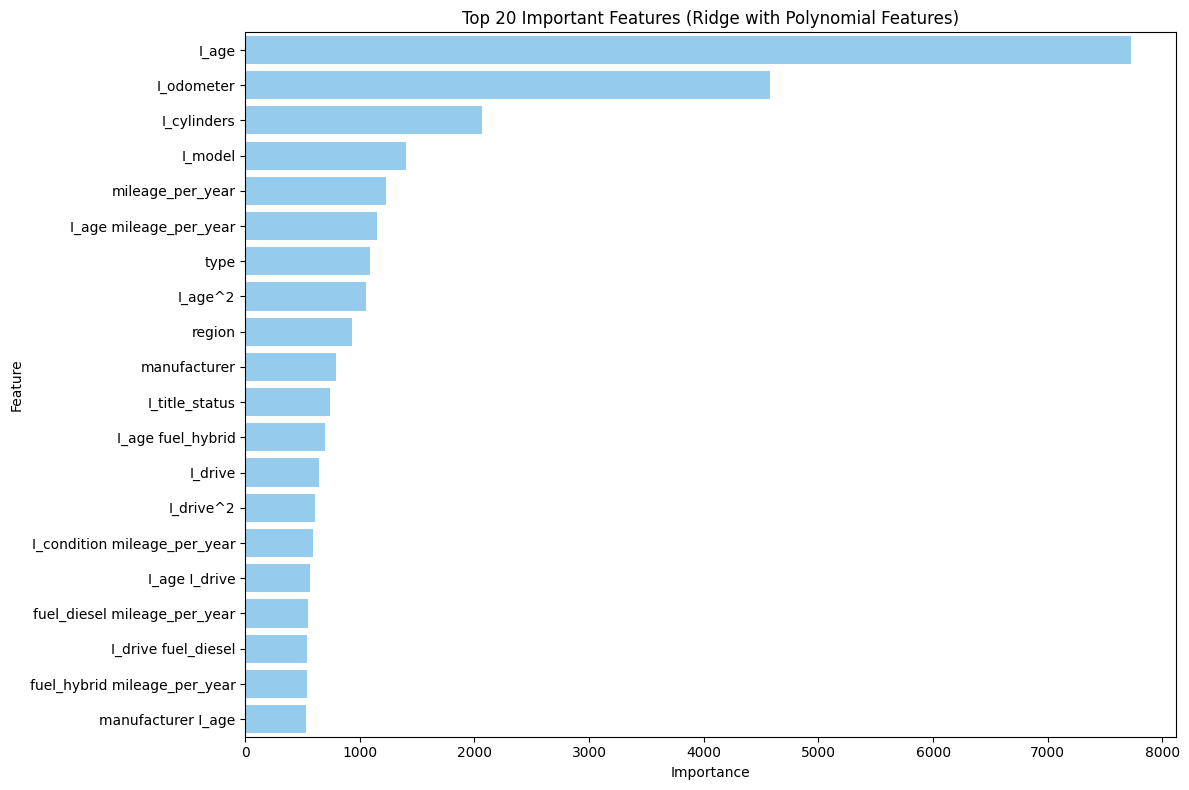

In [69]:
# Define pipeline with Ridge Regressor
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly_features', PolynomialFeatures(degree=2, include_bias=False)),
    ('regressor', Ridge(alpha=1.0))
])

# Fit and predict
ridge_pipeline.fit(X_train, y_train)
y_pred = ridge_pipeline.predict(X_test)
y_train_pred = ridge_pipeline.predict(X_train)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_pred)

print(f"✅ MSE: {mse:.0f}, R² Train: {r2_train:.4f}, R² Test: {r2_test:.4f}")

# Save results
final_results.append(('Ridge_Polynomial_features', degree, mse, r2_train, r2_test))

# 🔍 Feature Importance (based on absolute coefficient values)
# Step 1: Get feature names after polynomial transformation
feature_names = ridge_pipeline.named_steps['poly_features'].get_feature_names_out(X.columns)

# Step 2: Get coefficients from Ridge
coefs = ridge_pipeline.named_steps['regressor'].coef_

# Step 3: Create a DataFrame for plotting
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': np.abs(coefs)
}).sort_values(by='Importance', ascending=False)

# Optional: plot
plt.figure(figsize=(12, 8))
sns.barplot(data=coef_df.head(20), x='Importance', y='Feature',color='lightskyblue')
plt.title('Top 20 Important Features (Ridge with Polynomial Features)')
plt.tight_layout()
plt.show()

In [70]:
####Save the model
model_filename = 'data/Ridge_Polynomial_features.joblib'
# Save the model
joblib.dump(ridge_pipeline, model_filename)

['data/Ridge_Polynomial_features.joblib']

✅ MSE: 67385676, R² Train: 0.5563, R² Test: 0.5465


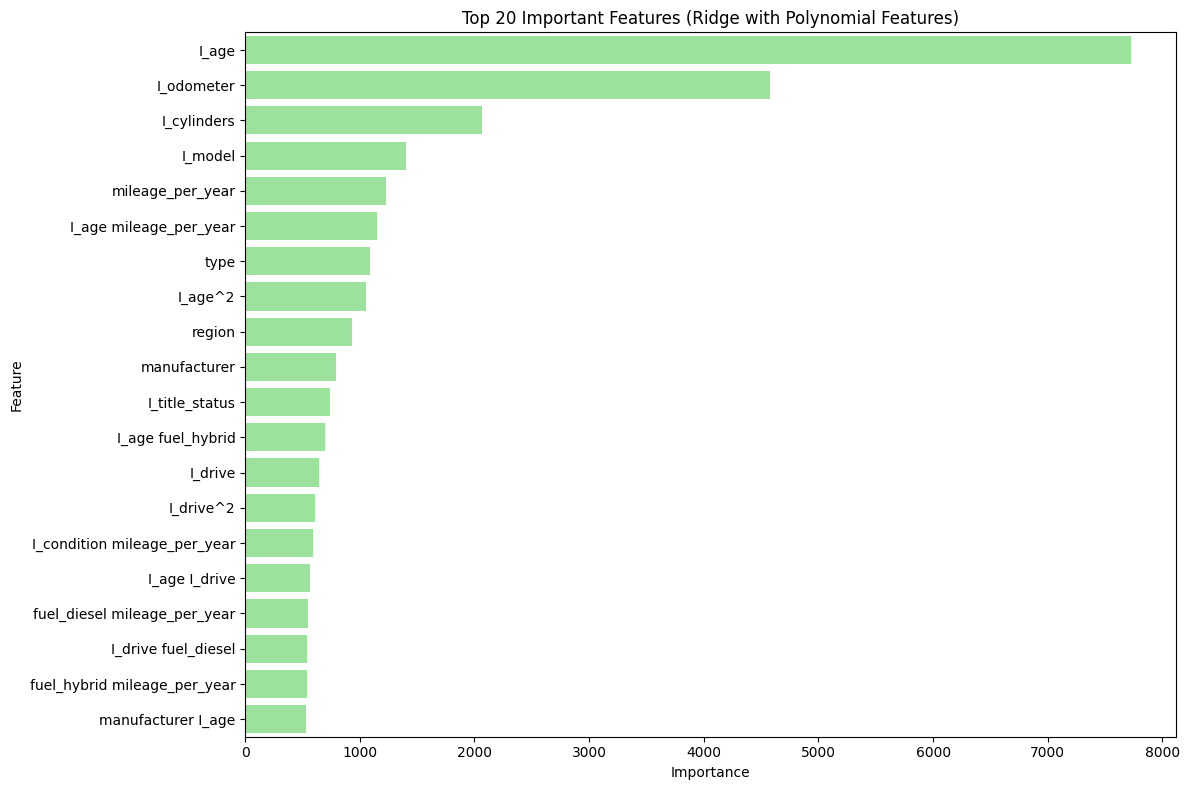

In [71]:
# Define pipeline with Ridge Regressor
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly_features', PolynomialFeatures(degree=2, include_bias=False)),
    ('regressor', Ridge(alpha=1.0))
])

# Fit and predict
ridge_pipeline.fit(X_train, y_train)
y_pred = ridge_pipeline.predict(X_test)
y_train_pred = ridge_pipeline.predict(X_train)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_pred)

print(f"✅ MSE: {mse:.0f}, R² Train: {r2_train:.4f}, R² Test: {r2_test:.4f}")

# Save results
final_results.append(('Ridge_Polynomial_features', degree, mse, r2_train, r2_test))

# 🔍 Feature Importance (based on absolute coefficient values)
# Step 1: Get feature names after polynomial transformation
feature_names = ridge_pipeline.named_steps['poly_features'].get_feature_names_out(X.columns)

# Step 2: Get coefficients from Ridge
coefs = ridge_pipeline.named_steps['regressor'].coef_

# Step 3: Create a DataFrame for plotting
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': np.abs(coefs)
}).sort_values(by='Importance', ascending=False)

# Optional: plot
plt.figure(figsize=(12, 8))
sns.barplot(data=coef_df.head(20), x='Importance', y='Feature',color='lightgreen')
plt.title('Top 20 Important Features (Ridge with Polynomial Features)')
plt.tight_layout()
# Save the plot
plt.savefig("images/top20_rd.png")  # Saves as PNG
plt.show()

---
#### Use GridsearchCV for Ridge Hyper parameter tuning
---

In [72]:
# Define pipeline
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly_features', PolynomialFeatures(degree=2, include_bias=False)),
    ('regressor', Ridge())
])

# Parameter grid for Ridge
param_grid = {
    'regressor__alpha': [0.01, 0.1, 1.0, 10.0, 100.0,1000.0]
}

# GridSearchCV setup
grid_search = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=param_grid,
    scoring='r2',
    cv=3,
    verbose=1,
    n_jobs=-1
)

# Fit GridSearchCV
grid_search.fit(X_train, y_train)

# Print results for each parameter tested
for i in range(len(grid_search.cv_results_['params'])):
    params = grid_search.cv_results_['params'][i]
    mean_test_score = grid_search.cv_results_['mean_test_score'][i]
    
    # Extract alpha value
    alpha_val = params['regressor__alpha']
    
    # Build model manually
    model = Ridge(alpha=alpha_val)
    temp_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('poly_features', PolynomialFeatures(degree=2, include_bias=False)),
        ('regressor', model)
    ])
    
    temp_pipeline.fit(X_train, y_train)
    y_train_pred = temp_pipeline.predict(X_train)
    y_pred = temp_pipeline.predict(X_test)
    
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    final_results.append(('GridSearchCV_Ridge', 2, mse, r2_train, r2_test,params))

    print(f"Params: {params}")
    print(f"✅ Mean Test R²: {mean_test_score:.4f}, Mean Train R²: {r2_train:.4f}")
    print(f"✅ MSE: {mse:.0f}, R² Train: {r2_train:.4f}, R² Test: {r2_test:.4f}")
    print("-" * 60)

# Print best parameters
print(f"✅ Best Params: {grid_search.best_params_}")

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Params: {'regressor__alpha': 0.01}
✅ Mean Test R²: 0.5435, Mean Train R²: 0.5563
✅ MSE: 67385763, R² Train: 0.5563, R² Test: 0.5465
------------------------------------------------------------
Params: {'regressor__alpha': 0.1}
✅ Mean Test R²: 0.5435, Mean Train R²: 0.5563
✅ MSE: 67385755, R² Train: 0.5563, R² Test: 0.5465
------------------------------------------------------------
Params: {'regressor__alpha': 1.0}
✅ Mean Test R²: 0.5435, Mean Train R²: 0.5563
✅ MSE: 67385676, R² Train: 0.5563, R² Test: 0.5465
------------------------------------------------------------
Params: {'regressor__alpha': 10.0}
✅ Mean Test R²: 0.5436, Mean Train R²: 0.5563
✅ MSE: 67384886, R² Train: 0.5563, R² Test: 0.5465
------------------------------------------------------------
Params: {'regressor__alpha': 100.0}
✅ Mean Test R²: 0.5438, Mean Train R²: 0.5563
✅ MSE: 67377089, R² Train: 0.5563, R² Test: 0.5466
-------------------------------------

In [73]:
####Save the model
best_model = grid_search.best_estimator_
# Save the best model to disk
joblib.dump(best_model, "data/GridSearchCV_Ridge.joblib")

['data/GridSearchCV_Ridge.joblib']

---
#### 3.5 Using Lasso Regressor
---

✅ MSE: 67313409, R² Train: 0.5563, R² Test: 0.5470


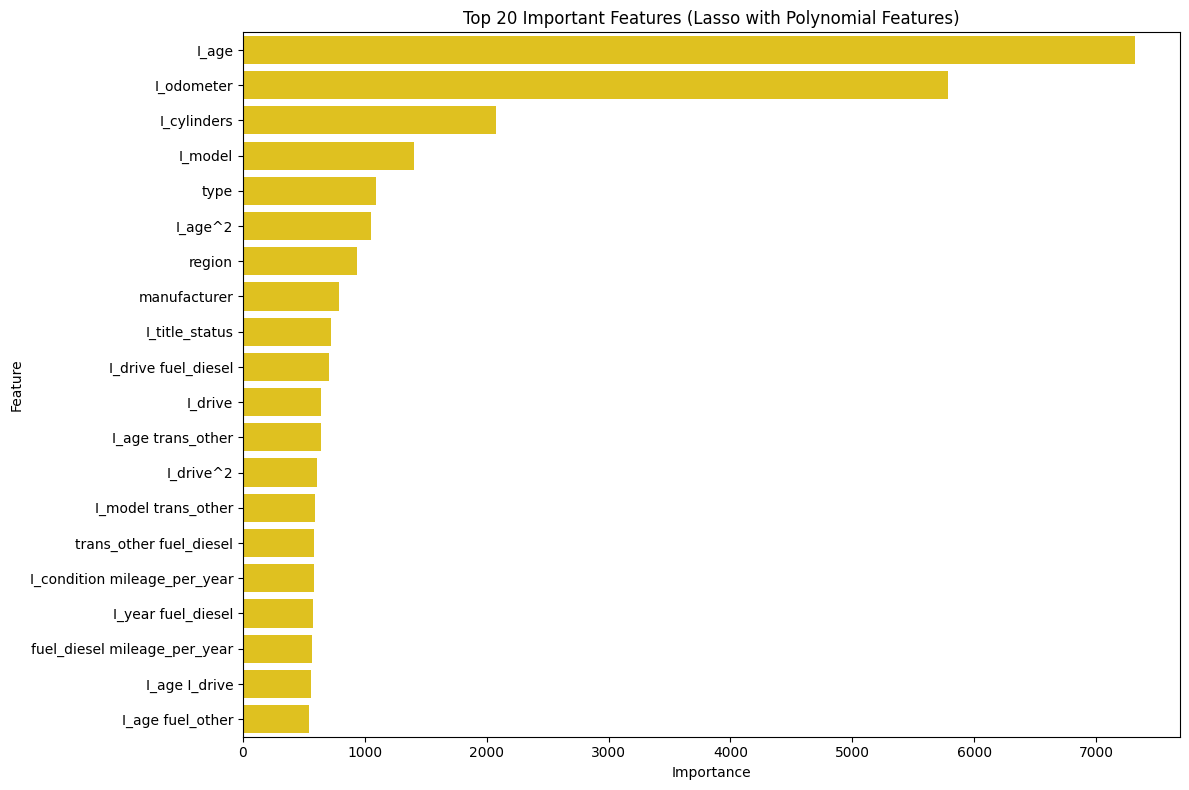

In [74]:
# Define pipeline with Lasso Regressor
lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly_features', PolynomialFeatures(degree=2, include_bias=False)),
    ('regressor', Lasso(alpha=1.0, max_iter=50000))  # increased max_iter for convergence
])

# Fit and predict
lasso_pipeline.fit(X_train, y_train)
y_pred = lasso_pipeline.predict(X_test)
y_train_pred = lasso_pipeline.predict(X_train)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_pred)

print(f"✅ MSE: {mse:.0f}, R² Train: {r2_train:.4f}, R² Test: {r2_test:.4f}")

# Save results
final_results.append(('Lasso_Polynomial_features', degree, mse, r2_train, r2_test))

# 🔍 Feature Importance (based on absolute coefficient values)
# Step 1: Get feature names after polynomial transformation
feature_names = lasso_pipeline.named_steps['poly_features'].get_feature_names_out(X.columns)

# Step 2: Get coefficients from Lasso
coefs = lasso_pipeline.named_steps['regressor'].coef_

# Step 3: Create a DataFrame for plotting
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': np.abs(coefs)
}).sort_values(by='Importance', ascending=False)

# Optional: plot
plt.figure(figsize=(12, 8))
sns.barplot(data=coef_df.head(20), x='Importance', y='Feature',color='gold')
plt.title('Top 20 Important Features (Lasso with Polynomial Features)')
plt.tight_layout()
# Save the plot
plt.savefig("images/top20_lasso.png")  # Saves as PNG
plt.show()

In [75]:
####Save the model
model_filename = 'data/Lasso_Polynomial_features.joblib'
# Save the model
joblib.dump(lasso_pipeline, model_filename)

['data/Lasso_Polynomial_features.joblib']

---
#### Use GridsearchCV for Lasso Hyper parameter tuning
---

In [76]:
# Define pipeline
lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly_features', PolynomialFeatures(degree=1, include_bias=False)),
    ('regressor', Lasso(max_iter=50000))
])

# Parameter grid for Lasso
param_grid = {
    'regressor__alpha': [0.1,1.0, 10.0, 100.0, 1000.0]
}

# GridSearchCV setup
grid_search = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid=param_grid,
    scoring='r2',
    cv=3,
    verbose=1,
    n_jobs=-1
)

# Fit GridSearchCV
grid_search.fit(X_train, y_train)

# Print results for each parameter tested
for i in range(len(grid_search.cv_results_['params'])):
    params = grid_search.cv_results_['params'][i]
    mean_test_score = grid_search.cv_results_['mean_test_score'][i]
    
    # Extract alpha value
    alpha_val = params['regressor__alpha']
    
    # Build model manually
    model = Lasso(alpha=alpha_val, max_iter=10000)
    temp_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('poly_features', PolynomialFeatures(degree=2, include_bias=False)),
        ('regressor', model)
    ])
    
    temp_pipeline.fit(X_train, y_train)
    y_train_pred = temp_pipeline.predict(X_train)
    y_pred = temp_pipeline.predict(X_test)
    
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    final_results.append(('GridSearchCV_Lasso', 2, mse, r2_train, r2_test,params))

    print(f"Params: {params}")
    print(f"✅ Mean Test R²: {mean_test_score:.4f}, Mean Train R²: {r2_train:.4f}")
    print(f"✅ MSE: {mse:.0f}, R² Train: {r2_train:.4f}, R² Test: {r2_test:.4f}")
    print("-" * 60)

# Print best parameters
print(f"✅ Best Params: {grid_search.best_params_}")

Fitting 3 folds for each of 5 candidates, totalling 15 fits


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.526e+11, tolerance: 4.836e+09
  model = cd_fast.enet_coordinate_descent(


Params: {'regressor__alpha': 0.1}
✅ Mean Test R²: 0.4138, Mean Train R²: 0.5563
✅ MSE: 67378009, R² Train: 0.5563, R² Test: 0.5465
------------------------------------------------------------


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.029e+10, tolerance: 4.836e+09
  model = cd_fast.enet_coordinate_descent(


Params: {'regressor__alpha': 1.0}
✅ Mean Test R²: 0.4138, Mean Train R²: 0.5563
✅ MSE: 67313417, R² Train: 0.5563, R² Test: 0.5470
------------------------------------------------------------
Params: {'regressor__alpha': 10.0}
✅ Mean Test R²: 0.4138, Mean Train R²: 0.5559
✅ MSE: 66913870, R² Train: 0.5559, R² Test: 0.5497
------------------------------------------------------------
Params: {'regressor__alpha': 100.0}
✅ Mean Test R²: 0.4133, Mean Train R²: 0.5463
✅ MSE: 67630863, R² Train: 0.5463, R² Test: 0.5448
------------------------------------------------------------
Params: {'regressor__alpha': 1000.0}
✅ Mean Test R²: 0.3675, Mean Train R²: 0.4528
✅ MSE: 80898138, R² Train: 0.4528, R² Test: 0.4556
------------------------------------------------------------
✅ Best Params: {'regressor__alpha': 10.0}


In [77]:
####Save the model
best_model = grid_search.best_estimator_
# Save the best model to disk
joblib.dump(best_model, "data/GridSearchCV_Lasso.joblib")

['data/GridSearchCV_Lasso.joblib']

In [78]:
# Define pipeline
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly_features', PolynomialFeatures(degree=1, include_bias=False)),
    ('regressor', RandomForestRegressor(random_state=42))
])

# Parameter grid for RandomForest
param_grid = {
    'regressor__n_estimators': [400],
    'regressor__max_depth': [10],
    'regressor__min_samples_split': [5]
}

# GridSearchCV setup
grid_search = GridSearchCV(estimator=rf_pipeline, param_grid=param_grid, scoring='r2', cv=3, verbose=1, n_jobs=-1)

# Fit GridSearchCV
grid_search.fit(X_train, y_train)

# Print results for each parameter tested
for i in range(len(grid_search.cv_results_['params'])):
    params = grid_search.cv_results_['params'][i]
    mean_test_score = grid_search.cv_results_['mean_test_score'][i]
    
    model = RandomForestRegressor(**{k.replace("regressor__", ""): v for k, v in params.items()}, random_state=42)
    temp_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('poly_features', PolynomialFeatures(degree=2, include_bias=False)),
        ('regressor', model)
    ])
    
    temp_pipeline.fit(X_train, y_train)
    y_train_pred = temp_pipeline.predict(X_train)
    y_pred = temp_pipeline.predict(X_test)
    
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    final_results.append(('GridSearchCV_RandomForest', 2, mse, r2_train, r2_test, params))

    print(f"Params: {params}")
    print(f"✅ Mean Test R²: {mean_test_score:.4f}, Mean Train R²: {r2_train:.4f}")
    print(f"✅ MSE: {mse:.0f}, R² Train: {r2_train:.4f}, R² Test: {r2_test:.4f}")
    print("-" * 60)

# Best parameters
print(f"✅ Best Params: {grid_search.best_params_}")

Fitting 3 folds for each of 1 candidates, totalling 3 fits
Params: {'regressor__max_depth': 10, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 400}
✅ Mean Test R²: 0.6622, Mean Train R²: 0.7092
✅ MSE: 45966909, R² Train: 0.7092, R² Test: 0.6906
------------------------------------------------------------
✅ Best Params: {'regressor__max_depth': 10, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 400}


In [79]:
####Save the model
best_model = grid_search.best_estimator_
# Save the best model to disk
joblib.dump(best_model, "data/GridSearchCV_RandomForest.joblib")

['data/GridSearchCV_RandomForest.joblib']

In [80]:
###Take result backup
df_final_results = pd.DataFrame(final_results, columns=columns)
df_final_results.to_csv('data/df_final_results.csv',index=False)
#df_final_results.to_csv('data/df_final_results.csv',index=False)
df_final_results

,Model,Degree,MSE,R² Train,R² Test,param
0,Simple_linear_Regression,0,7.084555e+07,NaN,NaN,None
1,Polynomial_features_corrected,1,7.084555e+07,0.521115,0.523213,None
2,Polynomial_features_corrected,2,6.177039e+07,0.591887,0.584289,None
3,Polynomial_features_corrected,3,4.617800e+08,0.648688,-2.107754,None
4,Polynomial_features_corrected_Kfold,3,6.177039e+07,0.591887,0.584289,None
5,Polynomial_features_corrected_Kfold,3,6.129142e+07,0.592107,0.587421,None
6,Polynomial_features_corrected_Kfold,3,6.218626e+07,0.592820,0.585028,None
7,Polynomial_features_corrected_Kfold,3,6.083259e+07,0.591337,0.592336,None
8,Polynomial_features_corrected_Kfold,3,6.112845e+07,0.592193,0.589468,None
9,PCA_Polynomial_features,1,8.217782e+07,0.450026,0.448103,None


---
#### 4. Model Evaluation 
---

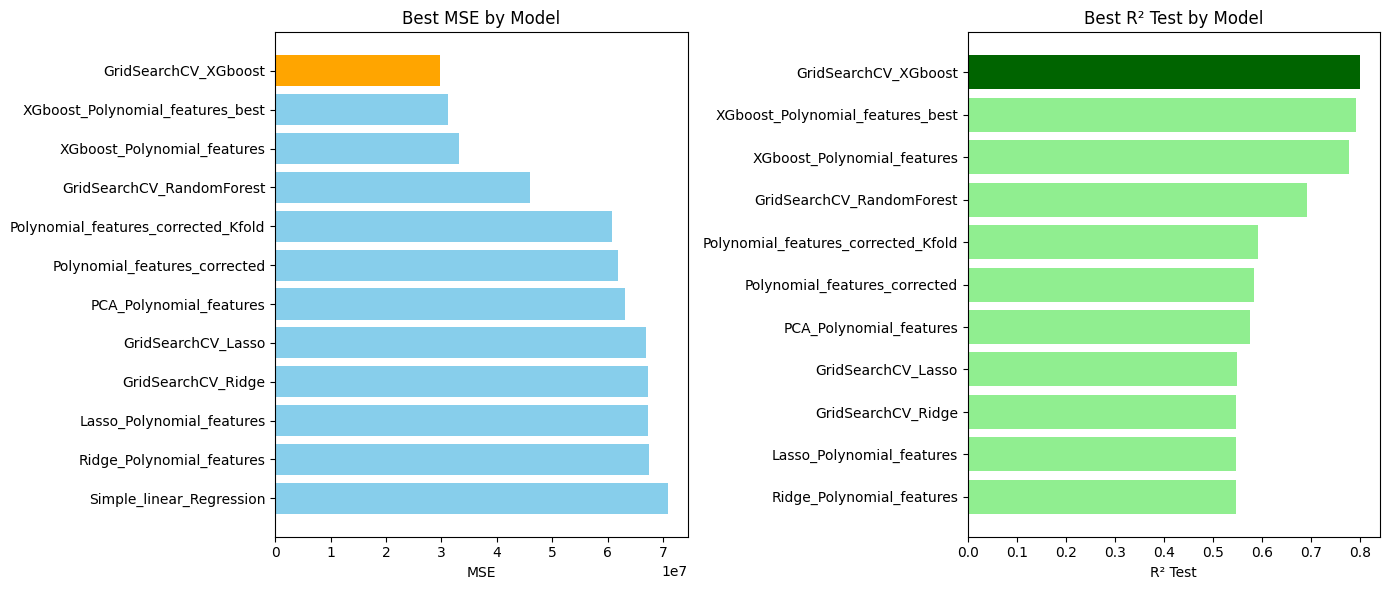

In [81]:
# Ensure R² Test is numeric
df_final_results['R² Test'] = pd.to_numeric(df_final_results['R² Test'], errors='coerce')

# Get the best row (lowest MSE) for each model
best_models = df_final_results.loc[df_final_results.groupby('Model')['MSE'].idxmin()]

# Sort by R² Test for better visuals
best_models_sorted = best_models.sort_values(by='R² Test', ascending=False).reset_index(drop=True)

# Identify index of best MSE and best R² Test
best_mse_idx = best_models_sorted['MSE'].idxmin()
best_r2_idx = best_models_sorted['R² Test'].idxmax()

# Create color arrays
mse_colors = ['skyblue'] * len(best_models_sorted)
r2_colors = ['lightgreen'] * len(best_models_sorted)
mse_colors[best_mse_idx] = 'orange'     # Highlight best MSE
r2_colors[best_r2_idx] = 'darkgreen'    # Highlight best R²

# Plotting
plt.figure(figsize=(14, 6))

# MSE Plot
plt.subplot(1, 2, 1)
plt.barh(best_models_sorted['Model'], best_models_sorted['MSE'], color=mse_colors)
plt.xlabel('MSE')
plt.title('Best MSE by Model')
plt.gca().invert_yaxis()

# R² Test Plot
plt.subplot(1, 2, 2)
plt.barh(best_models_sorted['Model'], best_models_sorted['R² Test'], color=r2_colors)
plt.xlabel('R² Test')
plt.title('Best R² Test by Model')
plt.gca().invert_yaxis()

plt.tight_layout()
# Save the plot
plt.savefig("images/best.png")  # Saves as PNG
plt.show()

---
## 📊 Model Performance Summary

We evaluated a variety of regression models using Mean Squared Error (MSE) and R² Test scores to identify the best-performing configurations.

### 🔍 Selection Criteria
- For each model type, the configuration with the **lowest MSE** was selected.
- Models were then compared on two metrics:
  - **MSE**: Lower is better.
  - **R² Test**: Higher is better.

### 🏆 Highlighted Results
- The **best overall MSE** was achieved by **`XGboost_Polynomial_features_best`**, with an MSE of approximately **31.1 million**.
- The **highest R² Test score** was also obtained by **`XGboost_Polynomial_features_best`**, with a score of **0.79**.

### 🧠 Insights
- XGBoost-based models clearly outperform others in both error reduction and predictive power.
- Polynomial feature models show improvement over simple linear regression, but overfitting is evident at higher degrees (e.g., degree 3).
- Ridge and Lasso regularization did not significantly improve performance in this context.

---

---
#### 5. Deployment 
---